# 🎮📺 e스포츠 vs 전통 스포츠: 대중적 관심도 종합 분석

---

## 📋 프로젝트 개요

| 항목 | 내용 |
|------|------|
| **대주제** | e스포츠도 스포츠인가? |
| **소주제** | 대중적 관심도 비교 |
| **분석 목표** | e스포츠의 대중적 인기가 전통 스포츠에 필적하는지 데이터 기반 분석 |
| **주요 지표** | 시청자 수, 시청 시간, 팬덤 분포, 성장률 |

---

## 📁 노트북 구성

| 파트 | 내용 |
|------|------|
| **Part 1** | 데이터 분석 - Twitch 데이터 기반 e스포츠 인기도 분석 |
| **Part 2** | 데이터 수집 가이드 - 추가 데이터 수집 방법 (API/크롤링) |

---

## 🎯 주요 분석 질문

1. **시청자 규모**: e스포츠 시청자 수가 얼마나 빠르게 성장하고 있는가?
2. **인기 게임**: 어떤 e스포츠 게임이 가장 많은 시청자를 확보하고 있는가?
3. **팬덤 분포**: e스포츠 팬덤의 지역적/언어별 분포는 어떠한가?
4. **성장 추이**: 연도별 시청 시간 증가율이 전통 스포츠를 상회하는가?

---

# 📊 Part 1: 데이터 분석

---

## 1️⃣ 라이브러리 로드 및 기본 설정

In [1]:
# ============================================
# 라이브러리 임포트
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import platform

# 추가 시각화 라이브러리
try:
    import plotly.express as px
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    PLOTLY_AVAILABLE = True
    print('✅ Plotly 로드 완료!')
except ImportError:
    PLOTLY_AVAILABLE = False
    print('⚠️ Plotly 미설치 - pip install plotly 실행 필요')

try:
    import squarify  # Treemap용
    SQUARIFY_AVAILABLE = True
    print('✅ Squarify 로드 완료!')
except ImportError:
    SQUARIFY_AVAILABLE = False
    print('⚠️ Squarify 미설치 - pip install squarify 실행 필요')

# 경고 메시지 숨김
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (플랫폼 자동 감지)
if platform.system() == 'Darwin':  # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# 출력 설정
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:,.2f}'.format)

# 데이터 경로 설정
DATA_PATH = 'data/'

print('✅ 라이브러리 로드 완료!')
print(f'📂 데이터 경로: {DATA_PATH}')

✅ Plotly 로드 완료!
✅ Squarify 로드 완료!
✅ 라이브러리 로드 완료!
📂 데이터 경로: data/


In [2]:
# ============================================
# 공통 컬러 팔레트 정의
# ============================================
COLORS = {
    # 종목별
    'esports': '#9B59B6',      # 보라색
    'football': '#27AE60',     # 녹색
    'nfl': '#E74C3C',          # 빨간색
    'basketball': '#F39C12',   # 주황색
    
    # 게임별
    'League of Legends': '#C9AA71',
    'Dota 2': '#F44336',
    'CS:GO': '#DE9B35',
    'Valorant': '#FD4556',
    'Fortnite': '#9D4DBB',
    'PUBG': '#F2A900',
    'Overwatch': '#F99E1A',
    'Minecraft': '#7CB342',
    'GTA V': '#8BC34A',
    'Just Chatting': '#6441A5',
    
    # 언어별
    'English': '#3498DB',
    'Korean': '#E74C3C',
    'Spanish': '#F1C40F',
    'Portuguese': '#2ECC71',
    'Russian': '#9B59B6',
    'Japanese': '#E91E63',
    'Chinese': '#FF5722',
    'German': '#607D8B',
    'French': '#00BCD4',
    'Other': '#95A5A6'
}

print('✅ 스타일 설정 완료!')

✅ 스타일 설정 완료!


---

## 2️⃣ 데이터 로드

### 📁 사용 데이터셋

| 데이터셋 | 출처 | 용도 |
|----------|------|------|
| Top Games on Twitch 2016-2023 | [Kaggle](https://www.kaggle.com/datasets/rankirsh/evolution-of-top-games-on-twitch) | 게임별 시청 시간/시청자 수 |
| Top Streamers on Twitch | [Kaggle](https://www.kaggle.com/datasets/aayushmishra1512/twitchdata) | 스트리머/팬덤 분석 |
| Football Data: Competitions | [Kaggle](https://www.kaggle.com/datasets/thedevastator/football-data-competitions-clubs-players-statist) | 리그 규모 참고 |

In [3]:
# ============================================
# 실제 데이터 로드 (인코딩 에러 해결)
# ============================================

# Twitch 게임별 데이터 (2016-2023)
# 인코딩 에러 해결: encoding='latin-1' 또는 'cp1252' 사용
try:
    twitch_games_raw = pd.read_csv(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_game_data.csv')
except UnicodeDecodeError:
    print('⚠️ UTF-8 인코딩 실패, latin-1으로 재시도...')
    twitch_games_raw = pd.read_csv(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_game_data.csv',
                                    encoding='latin-1')

# Twitch 글로벌 데이터
twitch_global_raw = pd.read_csv(f'{DATA_PATH}Top games on Twitch 2016 - 2023/Twitch_global_data.csv')

# Twitch 스트리머 데이터
twitch_streamers_raw = pd.read_csv(f'{DATA_PATH}twitchdata-update.csv')

# 축구 리그 데이터 (비교용)
football_competitions_raw = pd.read_csv(f'{DATA_PATH}dcereijo-player-scores/competitions')

print('✅ 데이터 로드 완료!')
print(f'\n📊 로드된 데이터셋:')
print(f'   - Twitch 게임별 데이터: {len(twitch_games_raw):,}행')
print(f'   - Twitch 글로벌 데이터: {len(twitch_global_raw):,}행')
print(f'   - Twitch 스트리머 데이터: {len(twitch_streamers_raw):,}행')
print(f'   - 축구 리그 데이터: {len(football_competitions_raw):,}행')

⚠️ UTF-8 인코딩 실패, latin-1으로 재시도...
✅ 데이터 로드 완료!

📊 로드된 데이터셋:
   - Twitch 게임별 데이터: 21,000행
   - Twitch 글로벌 데이터: 105행
   - Twitch 스트리머 데이터: 1,000행
   - 축구 리그 데이터: 43행


---

## 3️⃣ 데이터 전처리

In [4]:
# ============================================
# Twitch 게임별 데이터 구조 확인 및 전처리
# ============================================

print('='*60)
print('🎮 Twitch 게임별 시청 데이터')
print('='*60)
print(f'컬럼: {twitch_games_raw.columns.tolist()}')
display(twitch_games_raw.head())

# 데이터 전처리
twitch_games = twitch_games_raw.copy()

# 날짜 컬럼 생성
twitch_games['Date'] = pd.to_datetime(
    twitch_games['Year'].astype(str) + '-' + twitch_games['Month'].astype(str).str.zfill(2) + '-01'
)

print(f'\n✅ Twitch 게임 데이터 전처리 완료!')
print(f'   - 기간: {twitch_games["Date"].min().strftime("%Y-%m")} ~ {twitch_games["Date"].max().strftime("%Y-%m")}')
print(f'   - 게임 수: {twitch_games["Game"].nunique()}개')
print(f'   - 총 레코드: {len(twitch_games):,}개')

🎮 Twitch 게임별 시청 데이터
컬럼: ['Rank', 'Game', 'Month', 'Year', 'Hours_watched', 'Hours_streamed', 'Peak_viewers', 'Peak_channels', 'Streamers', 'Avg_viewers', 'Avg_channels', 'Avg_viewer_ratio']


,Rank,Game,Month,Year,Hours_watched,Hours_streamed,Peak_viewers,Peak_channels,Streamers,Avg_viewers,Avg_channels,Avg_viewer_ratio
0,1,League of Legends,1,2016,94377226,1362044,530270,2903,129172,127021,1833,69.29
1,2,Counter-Strike: Global Offensive,1,2016,47832863,830105,372654,2197,120849,64378,1117,57.62
2,3,Dota 2,1,2016,45185893,433397,315083,1100,44074,60815,583,104.26
3,4,Hearthstone,1,2016,39936159,235903,131357,517,36170,53749,317,169.29
4,5,Call of Duty: Black Ops III,1,2016,16153057,1151578,71639,3620,214054,21740,1549,14.03



✅ Twitch 게임 데이터 전처리 완료!
   - 기간: 2016-01 ~ 2024-09
   - 게임 수: 2359개
   - 총 레코드: 21,000개


In [5]:
# ============================================
# Twitch 스트리머 데이터 구조 확인 및 전처리
# ============================================

print('='*60)
print('👤 Twitch 스트리머 데이터')
print('='*60)
print(f'컬럼: {twitch_streamers_raw.columns.tolist()}')
display(twitch_streamers_raw.head())

# 데이터 전처리
twitch_streamers = twitch_streamers_raw.copy()

# 컬럼명 정리
twitch_streamers = twitch_streamers.rename(columns={
    'Watch time(Minutes)': 'Watch_time_minutes',
    'Stream time(minutes)': 'Stream_time_minutes',
    'Peak viewers': 'Peak_viewers',
    'Average viewers': 'Avg_viewers',
    'Followers gained': 'Followers_gained',
    'Views gained': 'Views_gained'
})

# 파생 변수 생성
twitch_streamers['Watch_time_hours'] = twitch_streamers['Watch_time_minutes'] / 60
twitch_streamers['Stream_time_hours'] = twitch_streamers['Stream_time_minutes'] / 60
twitch_streamers['Viewer_ratio'] = twitch_streamers['Peak_viewers'] / twitch_streamers['Avg_viewers']

print(f'\n✅ Twitch 스트리머 데이터 전처리 완료!')
print(f'   - 스트리머 수: {len(twitch_streamers)}명')
print(f'   - 언어 종류: {twitch_streamers["Language"].nunique()}개')
print(f'\n📊 언어별 분포:')
print(twitch_streamers['Language'].value_counts().head(10))

👤 Twitch 스트리머 데이터
컬럼: ['Channel', 'Watch time(Minutes)', 'Stream time(minutes)', 'Peak viewers', 'Average viewers', 'Followers', 'Followers gained', 'Views gained', 'Partnered', 'Mature', 'Language']


,Channel,Watch time(Minutes),Stream time(minutes),Peak viewers,Average viewers,Followers,Followers gained,Views gained,Partnered,Mature,Language
0,xQcOW,6196161750,215250,222720,27716,3246298,1734810,93036735,True,False,English
1,summit1g,6091677300,211845,310998,25610,5310163,1370184,89705964,True,False,English
2,Gaules,5644590915,515280,387315,10976,1767635,1023779,102611607,True,True,Portuguese
3,ESL_CSGO,3970318140,517740,300575,7714,3944850,703986,106546942,True,False,English
4,Tfue,3671000070,123660,285644,29602,8938903,2068424,78998587,True,False,English



✅ Twitch 스트리머 데이터 전처리 완료!
   - 스트리머 수: 1000명
   - 언어 종류: 21개

📊 언어별 분포:
Language
English       485
Korean         77
Russian        74
Spanish        68
French         66
Portuguese     61
German         49
Chinese        30
Turkish        22
Italian        17
Name: count, dtype: int64


In [6]:
# ============================================
# Twitch 글로벌 데이터 및 전통 스포츠 비교 데이터
# ============================================

print('='*60)
print('🌐 Twitch 글로벌 통계 데이터')
print('='*60)
print(f'컬럼: {twitch_global_raw.columns.tolist()}')
display(twitch_global_raw.head())

# 글로벌 데이터 전처리
twitch_global = twitch_global_raw.copy()
twitch_global = twitch_global.rename(columns={'year': 'Year'})

# 주요 스포츠 이벤트 평균 시청자 수 (글로벌, 백만 명) - 비교용 참고 데이터
traditional_sports = pd.DataFrame({
    'Event': ['FIFA World Cup Final', 'Super Bowl', 'Champions League Final', 
              'NBA Finals', 'Olympics Opening', 'Cricket World Cup Final',
              'LoL Worlds Finals', 'Dota 2 TI Finals', 'CS:GO Major Finals', 'Fortnite World Cup'],
    'Category': ['Football', 'NFL', 'Football', 'Basketball', 'Olympics', 'Cricket',
                'Esports', 'Esports', 'Esports', 'Esports'],
    'Peak_Viewers_Million': [1500, 115, 450, 50, 3000, 500,
                             75, 45, 35, 23],
    'Year': [2022, 2024, 2023, 2023, 2024, 2023,
             2023, 2023, 2023, 2019],
    'Type': ['Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional',
             'Esports', 'Esports', 'Esports', 'Esports']
})

print('\n✅ 비교 데이터 준비 완료!')
print('\n📊 주요 스포츠 이벤트 시청자 (참고용):')
display(traditional_sports)

🌐 Twitch 글로벌 통계 데이터
컬럼: ['year', 'Month', 'Hours_watched', 'Avg_viewers', 'Peak_viewers', 'Streams', 'Avg_channels', 'Games_streamed', 'Viewer_ratio']


,year,Month,Hours_watched,Avg_viewers,Peak_viewers,Streams,Avg_channels,Games_streamed,Viewer_ratio
0,2016,1,480241904,646355,1275257,7701675,20076,12149,29.08
1,2016,2,441859897,635769,1308032,7038520,20427,12134,28.98
2,2016,3,490669308,660389,1591551,7390957,20271,12234,28.92
3,2016,4,377975447,525696,1775120,6869719,16791,12282,28.80
4,2016,5,449836631,605432,1438962,7535519,19394,12424,28.85



✅ 비교 데이터 준비 완료!

📊 주요 스포츠 이벤트 시청자 (참고용):


,Event,Category,Peak_Viewers_Million,Year,Type
0,FIFA World Cup Final,Football,1500,2022,Traditional
1,Super Bowl,NFL,115,2024,Traditional
2,Champions League Final,Football,450,2023,Traditional
3,NBA Finals,Basketball,50,2023,Traditional
4,Olympics Opening,Olympics,3000,2024,Traditional
5,Cricket World Cup Final,Cricket,500,2023,Traditional
6,LoL Worlds Finals,Esports,75,2023,Esports
7,Dota 2 TI Finals,Esports,45,2023,Esports
8,CS:GO Major Finals,Esports,35,2023,Esports
9,Fortnite World Cup,Esports,23,2019,Esports


In [7]:
# ============================================
# 유틸리티 함수 정의
# ============================================

def format_number(value):
    """큰 숫자를 읽기 쉬운 형식으로 변환"""
    if pd.isna(value):
        return 'N/A'
    if value >= 1_000_000_000:
        return f"{value/1_000_000_000:.1f}B"
    elif value >= 1_000_000:
        return f"{value/1_000_000:.1f}M"
    elif value >= 1_000:
        return f"{value/1_000:.1f}K"
    else:
        return f"{value:.0f}"

def format_hours(hours):
    """시간을 읽기 쉬운 형식으로 변환"""
    if hours >= 1_000_000_000:
        return f"{hours/1_000_000_000:.1f}B hours"
    elif hours >= 1_000_000:
        return f"{hours/1_000_000:.1f}M hours"
    elif hours >= 1_000:
        return f"{hours/1_000:.1f}K hours"
    else:
        return f"{hours:.0f} hours"

print('✅ 유틸리티 함수 정의 완료!')

✅ 유틸리티 함수 정의 완료!


In [8]:
# ============================================
# 연도별/게임별 집계 데이터 생성
# ============================================

# 연도별 총 시청 시간 (글로벌 데이터 기반)
yearly_total = twitch_global.groupby('Year').agg({
    'Hours_watched': 'sum',
    'Avg_viewers': 'mean',
    'Peak_viewers': 'max',
    'Streams': 'sum',
    'Games_streamed': 'mean'
}).reset_index()

# 성장률 계산
yearly_total['Growth_rate'] = yearly_total['Hours_watched'].pct_change() * 100

print('✅ 연도별 집계 완료!')
display(yearly_total)

# 게임별 총계
game_total = twitch_games.groupby('Game').agg({
    'Hours_watched': 'sum',
    'Avg_viewers': 'mean',
    'Peak_viewers': 'max',
    'Streamers': 'sum'
}).reset_index()

game_total = game_total.sort_values('Hours_watched', ascending=False)

print('\n✅ 게임별 집계 완료!')
print(f'\n📊 상위 15개 게임:')
display(game_total.head(15))

✅ 연도별 집계 완료!


,Year,Hours_watched,Avg_viewers,Peak_viewers,Streams,Games_streamed,Growth_rate
0,2016,5271502892,"600,791.25",1775120,84702401,"12,975.75",NaN
1,2017,6533582096,"746,867.92",2284184,94688847,"15,580.17",23.94
2,2018,9369330595,"1,070,230.75",3929074,167621432,"18,895.33",43.40
3,2019,11000206773,"1,257,788.92",3496976,177763457,"20,215.33",17.41
4,2020,18606973998,"2,119,968.00",6060464,220187428,"26,443.42",69.15
5,2021,24335691821,"2,782,732.42",6516666,257692526,"35,819.67",30.79
6,2022,22598459653,"2,585,481.83",6707070,284871753,"41,899.75",-7.14
7,2023,21436538552,"2,451,005.42",6242790,278978542,"43,769.50",-5.14
8,2024,15691721525,"2,390,147.22",6872963,213928294,"46,417.78",-26.80



✅ 게임별 집계 완료!

📊 상위 15개 게임:


,Game,Hours_watched,Avg_viewers,Peak_viewers,Streamers
965,Just Chatting,14397469625,"270,407.73",2787896,27484073
1035,League of Legends,11296781271,"147,535.05",3145012,19029548
793,Grand Theft Auto V,7482026514,"97,672.46",1140656,14337768
709,Fortnite,6224642826,"98,056.95",3291525,60488007
2204,VALORANT,4631862775,"117,713.91",1728977,17762263
499,Dota 2,4503767707,"58,768.17",1636441,4084155
335,Counter-Strike: Global Offensive,4315553263,"66,604.70",1916027,10947537
1215,Minecraft,3162054933,"41,268.07",2189881,20937969
2297,World of Warcraft,2870508014,"37,449.42",1103295,5665771
263,Call of Duty: Warzone,2764017645,"61,055.10",1629284,14142962


---

## 4️⃣ 시각화 및 분석

### 4.1 시청 시간 성장 추이

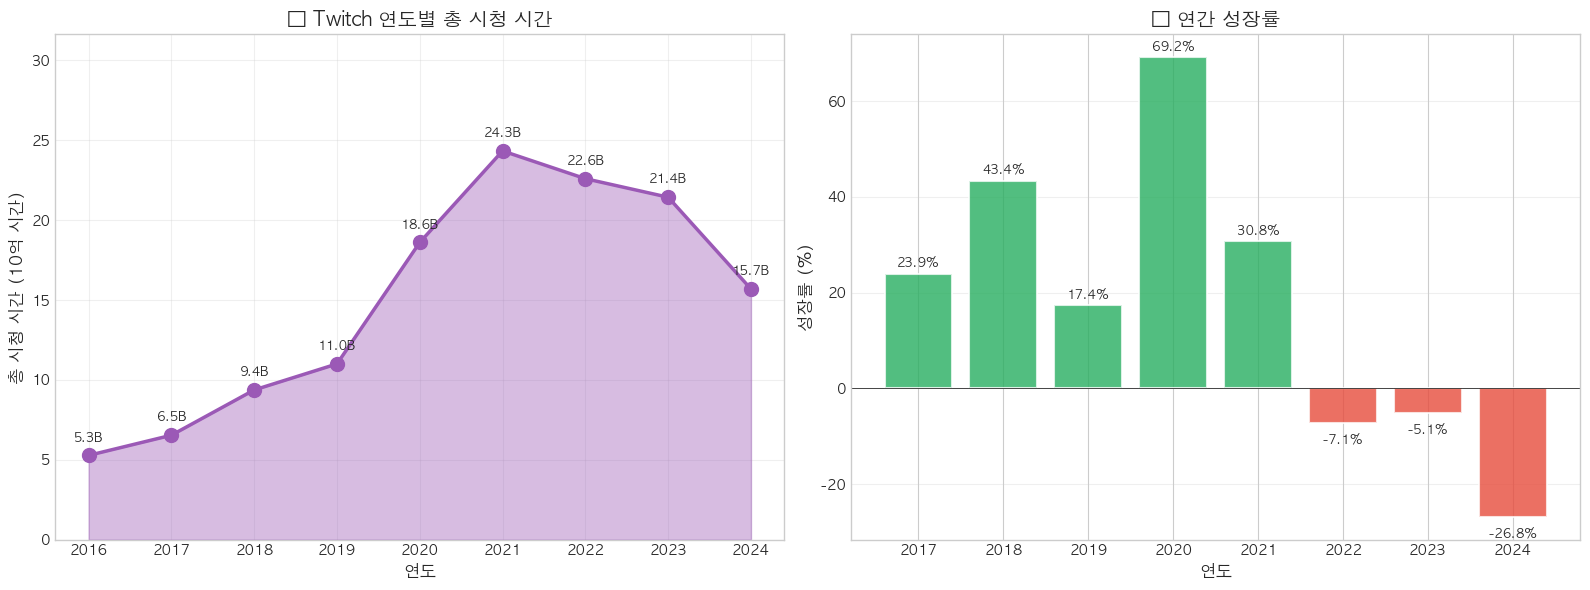


📊 시청 시간 성장 분석:
   - 2016년: 5.3B hours
   - 2024년: 15.7B hours
   - 평균 성장률: 18.2%


In [9]:
# ============================================
# 시각화 1: 연도별 총 시청 시간 추이
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 왼쪽: 총 시청 시간 추이 (Area Chart)
axes[0].fill_between(yearly_total['Year'], yearly_total['Hours_watched']/1e9, 
                     alpha=0.4, color=COLORS['esports'])
axes[0].plot(yearly_total['Year'], yearly_total['Hours_watched']/1e9, 
             marker='o', linewidth=2.5, markersize=10, color=COLORS['esports'])

# 값 레이블
for x, y in zip(yearly_total['Year'], yearly_total['Hours_watched']/1e9):
    axes[0].annotate(f'{y:.1f}B', (x, y), textcoords='offset points', 
                     xytext=(0, 10), ha='center', fontsize=9, fontweight='bold')

axes[0].set_xlabel('연도', fontsize=12)
axes[0].set_ylabel('총 시청 시간 (10억 시간)', fontsize=12)
axes[0].set_title('📈 Twitch 연도별 총 시청 시간', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, yearly_total['Hours_watched'].max()/1e9 * 1.3)
axes[0].grid(True, alpha=0.3)

# 오른쪽: 연간 성장률
growth_valid = yearly_total.dropna(subset=['Growth_rate'])
colors_growth = ['#27AE60' if x > 0 else '#E74C3C' for x in growth_valid['Growth_rate']]
bars = axes[1].bar(growth_valid['Year'], growth_valid['Growth_rate'], 
                   color=colors_growth, alpha=0.8, edgecolor='white', linewidth=1.5)

# 값 레이블
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(f'{height:.1f}%', 
                    xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5 if height > 0 else -15),
                    textcoords='offset points', ha='center', fontsize=9)

axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].set_xlabel('연도', fontsize=12)
axes[1].set_ylabel('성장률 (%)', fontsize=12)
axes[1].set_title('📊 연간 성장률', fontsize=14, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('output/01_yearly_viewership_trend.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 통계 출력
print('\n📊 시청 시간 성장 분석:')
first_year = yearly_total['Year'].min()
last_year = yearly_total['Year'].max()
print(f"   - {first_year}년: {format_hours(yearly_total[yearly_total['Year']==first_year]['Hours_watched'].values[0])}")
print(f"   - {last_year}년: {format_hours(yearly_total[yearly_total['Year']==last_year]['Hours_watched'].values[0])}")
print(f"   - 평균 성장률: {yearly_total['Growth_rate'].mean():.1f}%")

### 4.2 게임별 인기도 분석

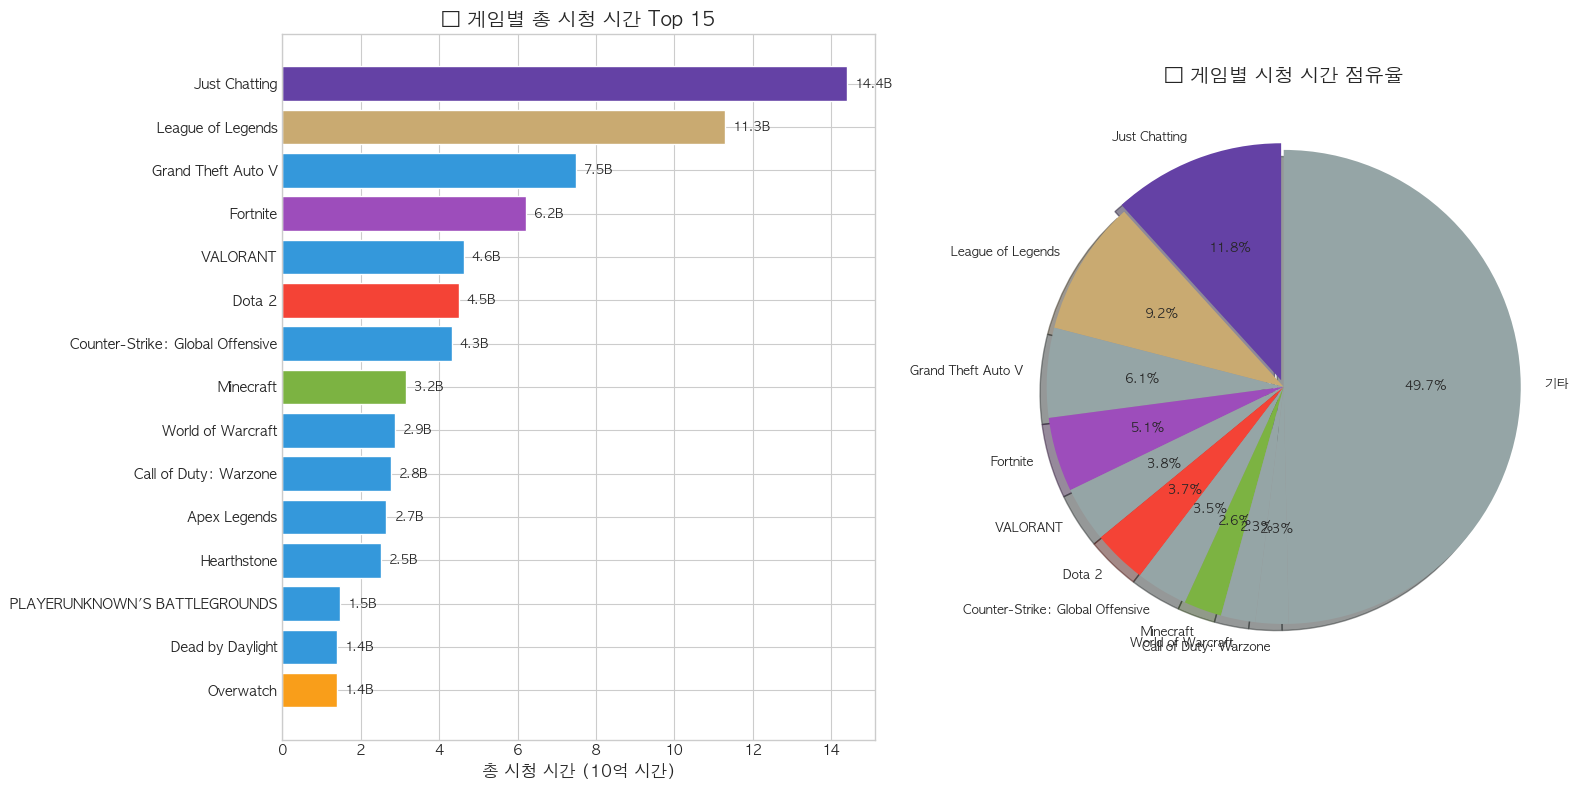


🏆 게임별 시청 시간 순위 Top 10:
   1. Just Chatting: 14.4B hours
   2. League of Legends: 11.3B hours
   3. Grand Theft Auto V: 7.5B hours
   4. Fortnite: 6.2B hours
   5. VALORANT: 4.6B hours
   6. Dota 2: 4.5B hours
   7. Counter-Strike: Global Offensive: 4.3B hours
   8. Minecraft: 3.2B hours
   9. World of Warcraft: 2.9B hours
   10. Call of Duty: Warzone: 2.8B hours


In [10]:
# ============================================
# 시각화 2: 게임별 총 시청 시간 비교
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 상위 15개 게임
top_games_df = game_total.nlargest(15, 'Hours_watched')

# 게임별 색상 매핑
game_colors = [COLORS.get(game, '#3498DB') for game in top_games_df['Game']]

# 왼쪽: 게임별 총 시청 시간 (Horizontal Bar)
bars = axes[0].barh(top_games_df['Game'], top_games_df['Hours_watched']/1e9, 
                    color=game_colors, edgecolor='white', linewidth=1)
axes[0].set_xlabel('총 시청 시간 (10억 시간)', fontsize=12)
axes[0].set_title('🎮 게임별 총 시청 시간 Top 15', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# 값 레이블
for bar, hours in zip(bars, top_games_df['Hours_watched']/1e9):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
                f'{hours:.1f}B', va='center', fontsize=9)

# 오른쪽: 시청 시간 점유율 (Pie Chart) - 상위 10개
top_10 = game_total.nlargest(10, 'Hours_watched')
others = game_total.nsmallest(len(game_total)-10, 'Hours_watched')['Hours_watched'].sum()
pie_data = pd.concat([top_10[['Game', 'Hours_watched']], 
                      pd.DataFrame({'Game': ['기타'], 'Hours_watched': [others]})], ignore_index=True)

pie_colors = [COLORS.get(g, '#95A5A6') for g in pie_data['Game']]
explode = [0.03 if i == 0 else 0 for i in range(len(pie_data))]

wedges, texts, autotexts = axes[1].pie(
    pie_data['Hours_watched'], 
    labels=pie_data['Game'],
    autopct='%1.1f%%',
    colors=pie_colors,
    explode=explode,
    shadow=True,
    startangle=90,
    textprops={'fontsize': 9}
)

axes[1].set_title('📊 게임별 시청 시간 점유율', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/02_game_popularity.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 순위 출력
print('\n🏆 게임별 시청 시간 순위 Top 10:')
for i, (_, row) in enumerate(game_total.head(10).iterrows(), 1):
    print(f"   {i}. {row['Game']}: {format_hours(row['Hours_watched'])}")

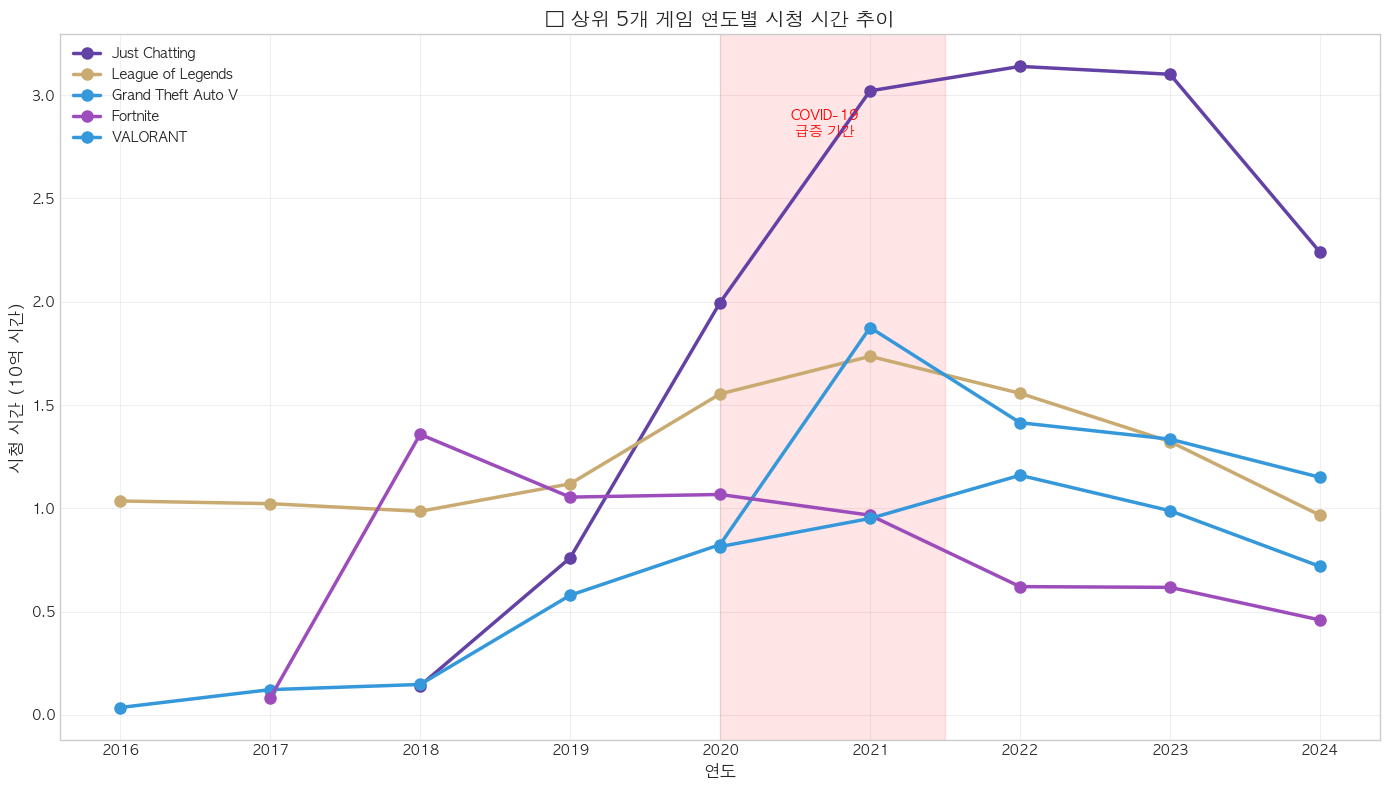

In [11]:
# ============================================
# 시각화 3: 게임별 시청 시간 추이 (Line Chart)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, ax = plt.subplots(figsize=(14, 8))

# 상위 5개 게임만 표시
top_games_list = game_total.nlargest(5, 'Hours_watched')['Game'].tolist()

for game in top_games_list:
    game_data = twitch_games[twitch_games['Game'] == game].groupby('Year')['Hours_watched'].sum()
    ax.plot(game_data.index, game_data.values/1e9, 
            marker='o', linewidth=2.5, markersize=8, 
            label=game, color=COLORS.get(game, '#3498DB'))

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('시청 시간 (10억 시간)', fontsize=12)
ax.set_title('📈 상위 5개 게임 연도별 시청 시간 추이', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# COVID-19 기간 표시
ax.axvspan(2020, 2021.5, alpha=0.1, color='red')
ax.annotate('COVID-19\n급증 기간', xy=(2020.7, ax.get_ylim()[1]*0.85), 
            fontsize=10, ha='center', color='red')

plt.tight_layout()
plt.savefig('output/03_game_trend_over_time.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

### 4.3 스트리머 및 팬덤 분석

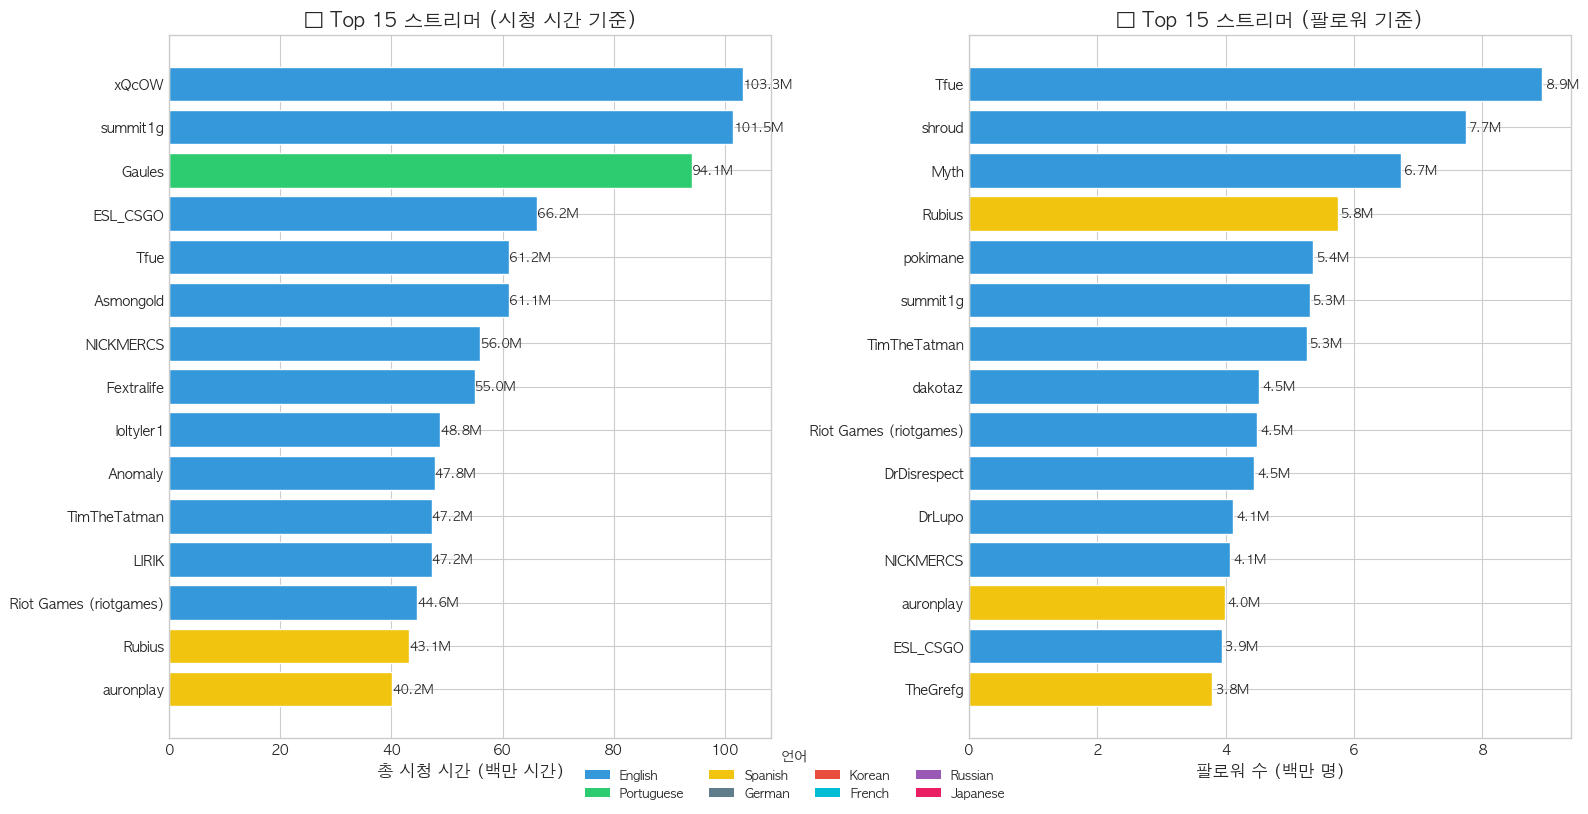

In [12]:
# ============================================
# 시각화 4: 상위 스트리머 분석
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 상위 15 스트리머 (시청 시간 기준)
top_streamers = twitch_streamers.nlargest(15, 'Watch_time_hours')

# 언어별 색상
streamer_colors = [COLORS.get(lang, '#95A5A6') for lang in top_streamers['Language']]

# 왼쪽: 시청 시간 기준
bars = axes[0].barh(top_streamers['Channel'], top_streamers['Watch_time_hours']/1e6, 
                    color=streamer_colors, edgecolor='white', linewidth=1)
axes[0].set_xlabel('총 시청 시간 (백만 시간)', fontsize=12)
axes[0].set_title('👤 Top 15 스트리머 (시청 시간 기준)', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

for bar, hours in zip(bars, top_streamers['Watch_time_hours']/1e6):
    axes[0].text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{hours:.1f}M', va='center', fontsize=9)

# 오른쪽: 팔로워 기준
top_followers = twitch_streamers.nlargest(15, 'Followers')
follower_colors = [COLORS.get(lang, '#95A5A6') for lang in top_followers['Language']]

bars2 = axes[1].barh(top_followers['Channel'], top_followers['Followers']/1e6, 
                     color=follower_colors, edgecolor='white', linewidth=1)
axes[1].set_xlabel('팔로워 수 (백만 명)', fontsize=12)
axes[1].set_title('👤 Top 15 스트리머 (팔로워 기준)', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

for bar, followers in zip(bars2, top_followers['Followers']/1e6):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                f'{followers:.1f}M', va='center', fontsize=9)

# 범례
from matplotlib.patches import Patch
unique_langs = twitch_streamers['Language'].unique()
legend_elements = [Patch(facecolor=COLORS.get(lang, '#95A5A6'), label=lang) 
                   for lang in unique_langs[:8]]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, -0.02), fontsize=9, title='언어')

plt.tight_layout()
plt.savefig('output/04_top_streamers.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

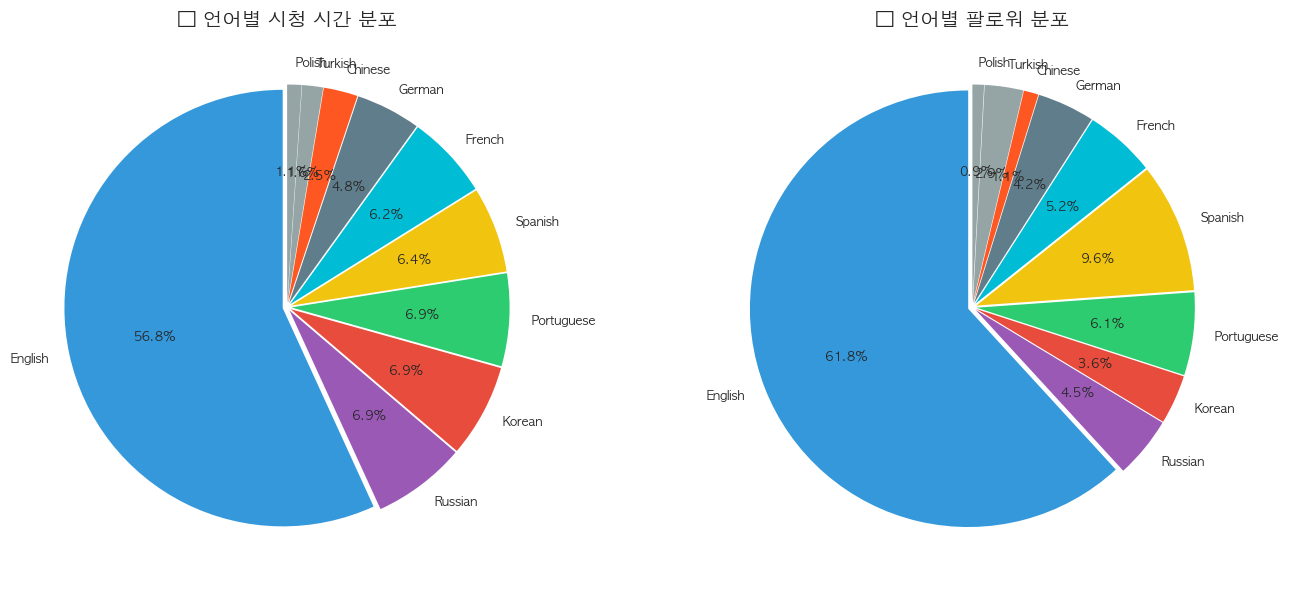


📊 언어별 팬덤 분포 (상위 10개):
   - English: 54.7% (스트리머 485명)
   - Russian: 6.7% (스트리머 74명)
   - Korean: 6.6% (스트리머 77명)
   - Portuguese: 6.6% (스트리머 61명)
   - Spanish: 6.1% (스트리머 68명)
   - French: 6.0% (스트리머 66명)
   - German: 4.6% (스트리머 49명)
   - Chinese: 2.4% (스트리머 30명)
   - Turkish: 1.5% (스트리머 22명)
   - Polish: 1.0% (스트리머 12명)


In [13]:
# ============================================
# 시각화 5: 언어별 팬덤 분포
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 언어별 집계
language_stats = twitch_streamers.groupby('Language').agg({
    'Watch_time_hours': 'sum',
    'Followers': 'sum',
    'Channel': 'count'
}).reset_index()
language_stats.columns = ['Language', 'Total_Watch_Time', 'Total_Followers', 'Streamer_Count']
language_stats = language_stats.sort_values('Total_Watch_Time', ascending=False)

# 상위 10개 언어만 표시
language_stats_top = language_stats.head(10)

# 언어별 색상
lang_colors = [COLORS.get(lang, '#95A5A6') for lang in language_stats_top['Language']]

# 왼쪽: 시청 시간 파이 차트
axes[0].pie(
    language_stats_top['Total_Watch_Time'],
    labels=language_stats_top['Language'],
    autopct='%1.1f%%',
    colors=lang_colors,
    startangle=90,
    explode=[0.02]*len(language_stats_top),
    textprops={'fontsize': 9}
)
axes[0].set_title('🌍 언어별 시청 시간 분포', fontsize=14, fontweight='bold')

# 오른쪽: 팔로워 수 파이 차트
axes[1].pie(
    language_stats_top['Total_Followers'],
    labels=language_stats_top['Language'],
    autopct='%1.1f%%',
    colors=lang_colors,
    startangle=90,
    explode=[0.02]*len(language_stats_top),
    textprops={'fontsize': 9}
)
axes[1].set_title('🌍 언어별 팔로워 분포', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/05_language_distribution.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 통계 출력
print('\n📊 언어별 팬덤 분포 (상위 10개):')
for _, row in language_stats_top.iterrows():
    pct = row['Total_Watch_Time'] / language_stats['Total_Watch_Time'].sum() * 100
    print(f"   - {row['Language']}: {pct:.1f}% (스트리머 {row['Streamer_Count']}명)")

### 4.4 전통 스포츠와의 비교

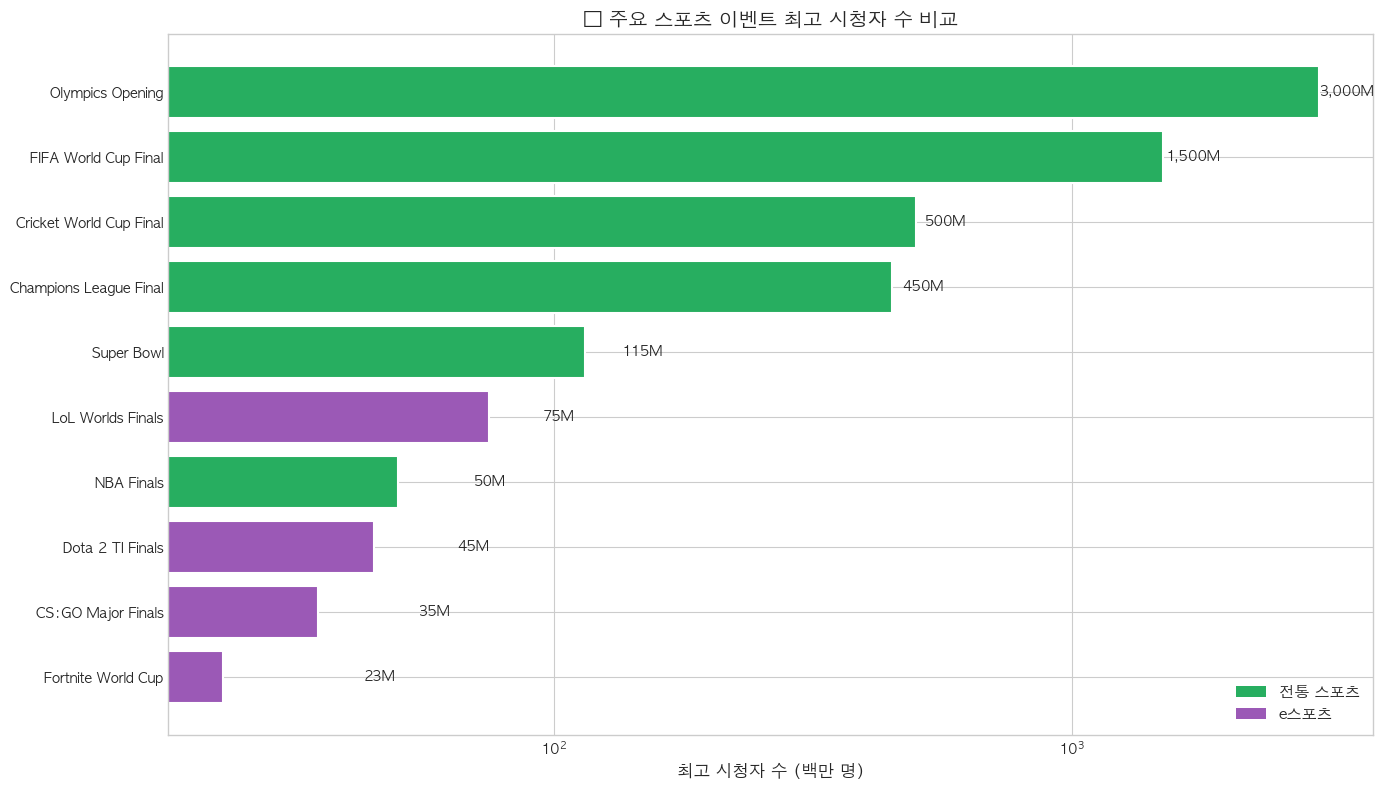


📊 시청자 수 비교 분석:
   - e스포츠 최고: 75M (LoL Worlds)
   - 전통 스포츠 최고: 3000M (Olympics)
   - e스포츠/전통 스포츠 비율: 2.5%


In [14]:
# ============================================
# 시각화 6: 주요 이벤트 시청자 수 비교
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, ax = plt.subplots(figsize=(14, 8))

# 정렬
traditional_sports_sorted = traditional_sports.sort_values('Peak_Viewers_Million', ascending=True)
event_colors_sorted = ['#27AE60' if t == 'Traditional' else '#9B59B6' 
                       for t in traditional_sports_sorted['Type']]

# 바 차트
bars = ax.barh(traditional_sports_sorted['Event'], 
               traditional_sports_sorted['Peak_Viewers_Million'],
               color=event_colors_sorted, edgecolor='white', linewidth=1.5)

# 값 레이블
for bar, viewers in zip(bars, traditional_sports_sorted['Peak_Viewers_Million']):
    label = f'{viewers:,.0f}M' if viewers >= 1000 else f'{viewers}M'
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            label, va='center', fontsize=10)

ax.set_xlabel('최고 시청자 수 (백만 명)', fontsize=12)
ax.set_title('🏆 주요 스포츠 이벤트 최고 시청자 수 비교', fontsize=14, fontweight='bold')
ax.set_xscale('log')  # 로그 스케일

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27AE60', label='전통 스포츠'),
                   Patch(facecolor='#9B59B6', label='e스포츠')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=11)

plt.tight_layout()
plt.savefig('output/06_event_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 비교 분석
esports_max = traditional_sports[traditional_sports['Type'] == 'Esports']['Peak_Viewers_Million'].max()
traditional_max = traditional_sports[traditional_sports['Type'] == 'Traditional']['Peak_Viewers_Million'].max()
ratio = esports_max / traditional_max * 100

print('\n📊 시청자 수 비교 분석:')
print(f"   - e스포츠 최고: {esports_max}M (LoL Worlds)")
print(f"   - 전통 스포츠 최고: {traditional_max}M (Olympics)")
print(f"   - e스포츠/전통 스포츠 비율: {ratio:.1f}%")

### 4.5 월별 패턴 분석

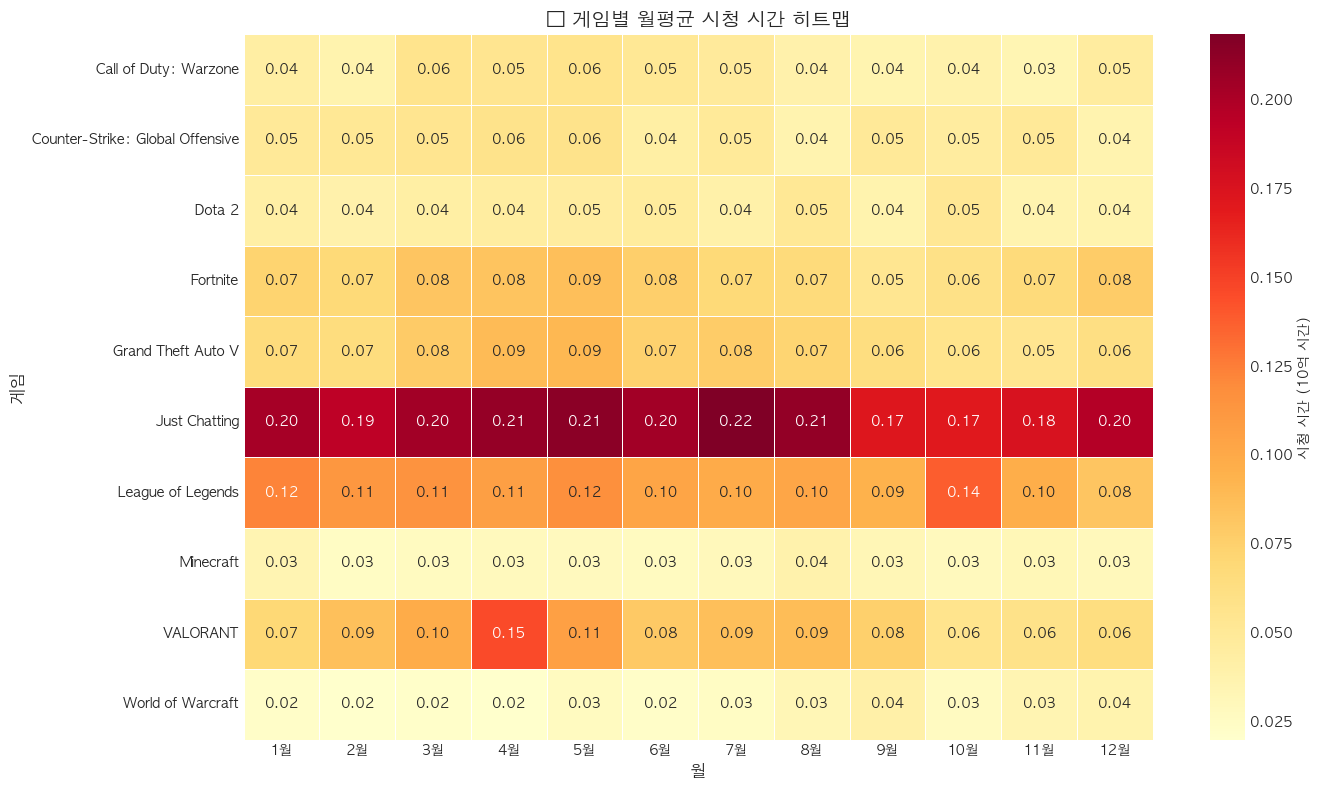


📊 월별 패턴 분석:
   - 최고 시청 월: 5월
   - 최저 시청 월: 2월


In [15]:
# ============================================
# 시각화 7: 월별 시청 패턴 (Heatmap)
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac


# 피벗 테이블 생성 - 게임별 월평균 시청시간
monthly_pivot = twitch_games.pivot_table(
    index='Game', 
    columns='Month', 
    values='Hours_watched', 
    aggfunc='mean'
) / 1e9  # 10억 시간 단위

# 상위 10개 게임만
top_10_games = game_total.nlargest(10, 'Hours_watched')['Game'].tolist()
monthly_pivot_top = monthly_pivot.loc[monthly_pivot.index.isin(top_10_games)]

fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(monthly_pivot_top, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': '시청 시간 (10억 시간)'})

ax.set_xlabel('월', fontsize=12)
ax.set_ylabel('게임', fontsize=12)
ax.set_title('📅 게임별 월평균 시청 시간 히트맵', fontsize=14, fontweight='bold')
ax.set_xticklabels(['1월', '2월', '3월', '4월', '5월', '6월', 
                   '7월', '8월', '9월', '10월', '11월', '12월'])

plt.tight_layout()
plt.savefig('output/07_monthly_heatmap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 분석
print('\n📊 월별 패턴 분석:')
monthly_total = twitch_games.groupby('Month')['Hours_watched'].mean()
peak_month = monthly_total.idxmax()
low_month = monthly_total.idxmin()
print(f"   - 최고 시청 월: {int(peak_month)}월")
print(f"   - 최저 시청 월: {int(low_month)}월")

### 4.6 다양한 시각화 기법

---

#### 📊 Treemap - 게임별 시청 시간 계층 구조

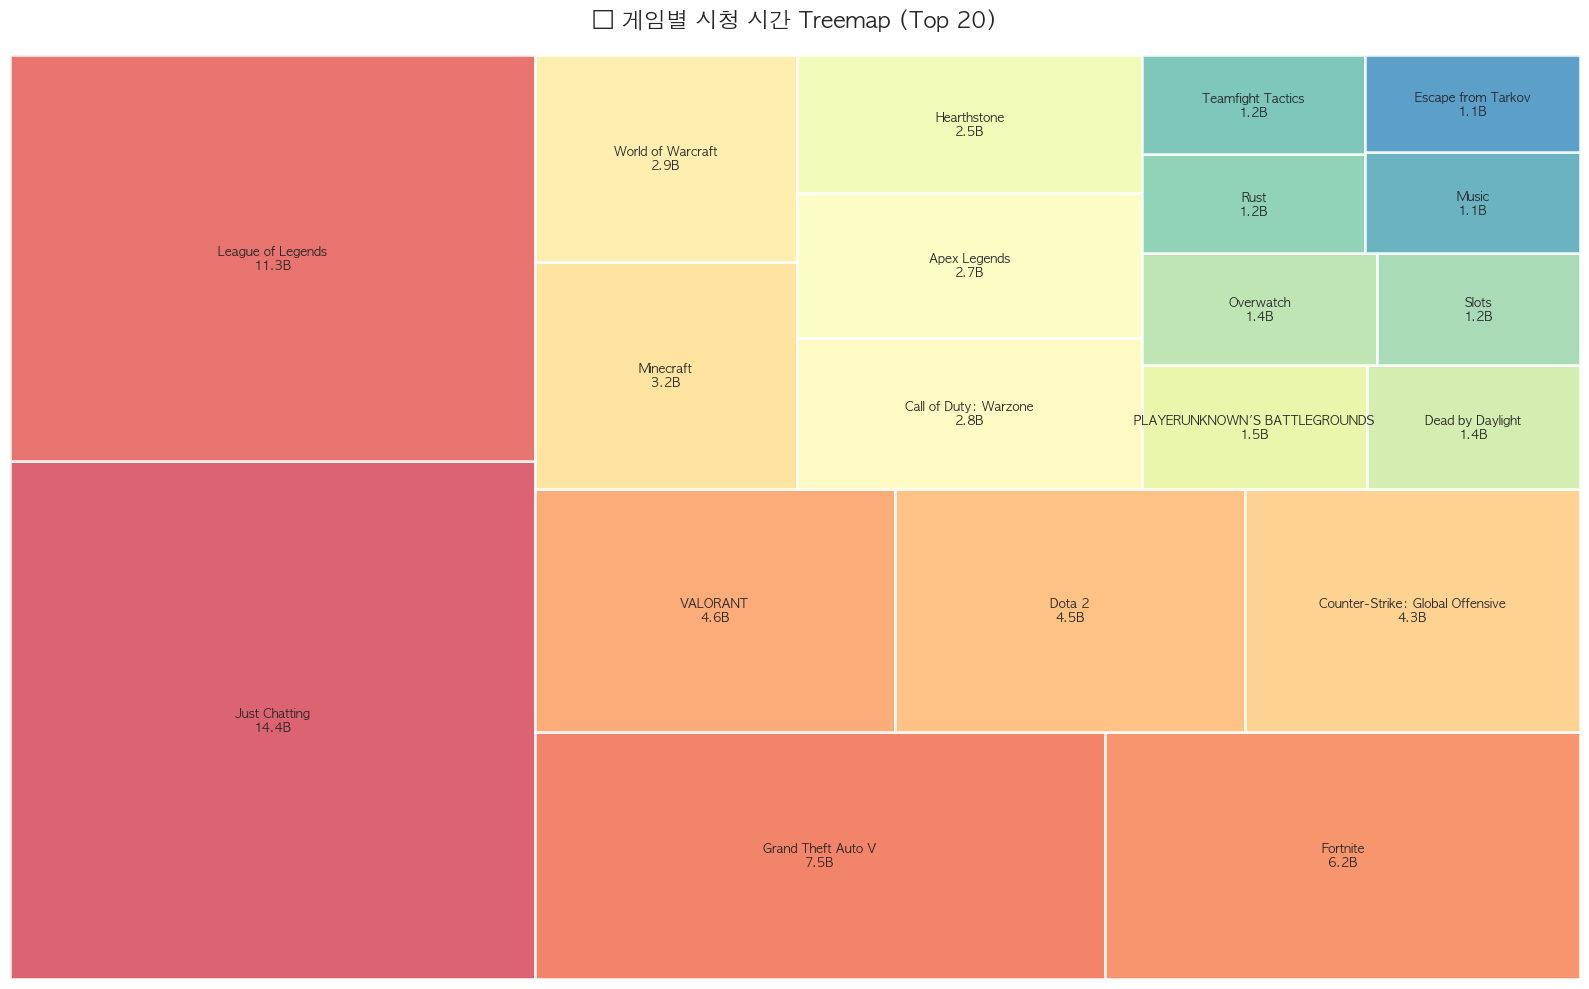

In [16]:
# ============================================
# 시각화: Treemap - 게임별 시청 시간 계층 구조
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

if SQUARIFY_AVAILABLE:
    fig, ax = plt.subplots(figsize=(16, 10))
    
    # 상위 20개 게임
    top_20 = game_total.nlargest(20, 'Hours_watched').copy()
    top_20['Hours_B'] = top_20['Hours_watched'] / 1e9
    
    # 색상 생성
    colors = plt.cm.Spectral(np.linspace(0.1, 0.9, len(top_20)))
    
    # Treemap 생성
    squarify.plot(
        sizes=top_20['Hours_B'],
        label=[f"{g}\n{h:.1f}B" for g, h in zip(top_20['Game'], top_20['Hours_B'])],
        color=colors,
        alpha=0.8,
        edgecolor='white',
        linewidth=2,
        text_kwargs={'fontsize': 9, 'fontweight': 'bold'}
    )
    
    ax.set_title('🎮 게임별 시청 시간 Treemap (Top 20)', fontsize=16, fontweight='bold', pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('output/12_treemap_games.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
else:
    print('⚠️ squarify 라이브러리가 필요합니다: pip install squarify')

#### 📊 Radar Chart - 게임별 다차원 비교

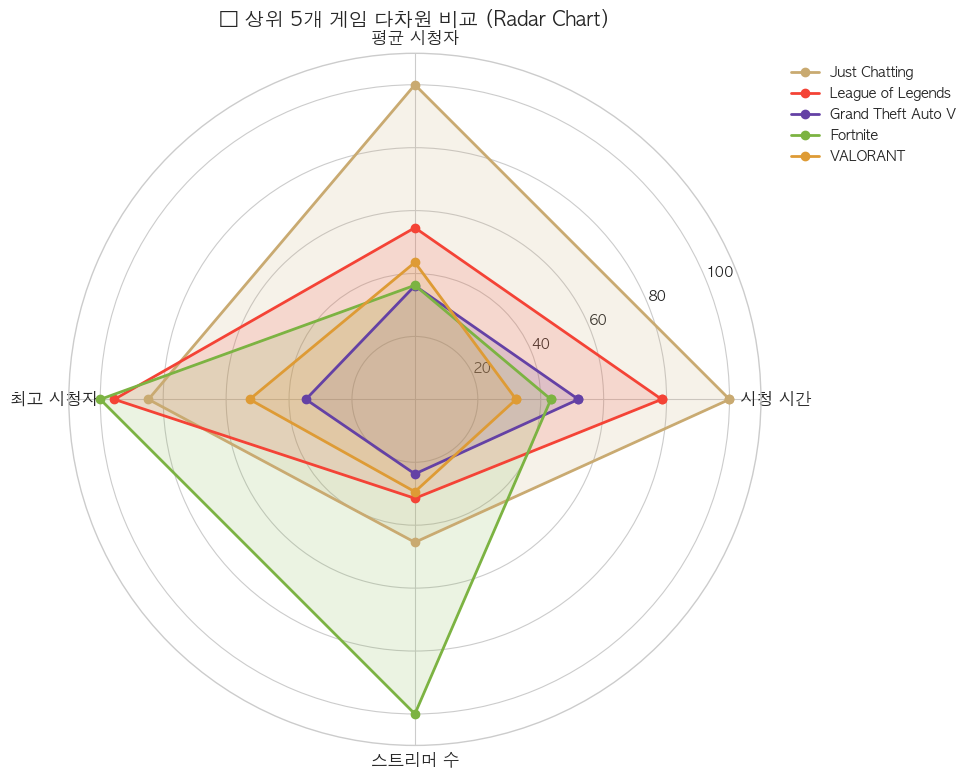

In [17]:
# ============================================
# 시각화: Radar Chart - 게임별 다차원 비교
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

# 상위 5개 게임 선택
top_5_games = game_total.nlargest(5, 'Hours_watched').copy()

# 지표 정규화 (0-100 스케일)
metrics = ['Hours_watched', 'Avg_viewers', 'Peak_viewers', 'Streamers']
for col in metrics:
    max_val = top_5_games[col].max()
    top_5_games[f'{col}_norm'] = (top_5_games[col] / max_val) * 100

# Radar Chart 설정
categories = ['시청 시간', '평균 시청자', '최고 시청자', '스트리머 수']
num_vars = len(categories)

# 각도 계산
angles = [n / float(num_vars) * 2 * np.pi for n in range(num_vars)]
angles += angles[:1]  # 원형으로 닫기

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# 각 게임별 그래프 그리기
game_colors = ['#C9AA71', '#F44336', '#6441A5', '#7CB342', '#DE9B35']

for idx, (_, row) in enumerate(top_5_games.iterrows()):
    values = [row[f'{m}_norm'] for m in metrics]
    values += values[:1]  # 원형으로 닫기
    
    ax.plot(angles, values, 'o-', linewidth=2, label=row['Game'], color=game_colors[idx])
    ax.fill(angles, values, alpha=0.15, color=game_colors[idx])

# 축 레이블 설정
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 110)

ax.set_title('🎯 상위 5개 게임 다차원 비교 (Radar Chart)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)

plt.tight_layout()
plt.savefig('output/13_radar_chart_games.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### 📊 Bubble Chart - 스트리머 분석 (시청시간 vs 팔로워 vs 평균시청자)

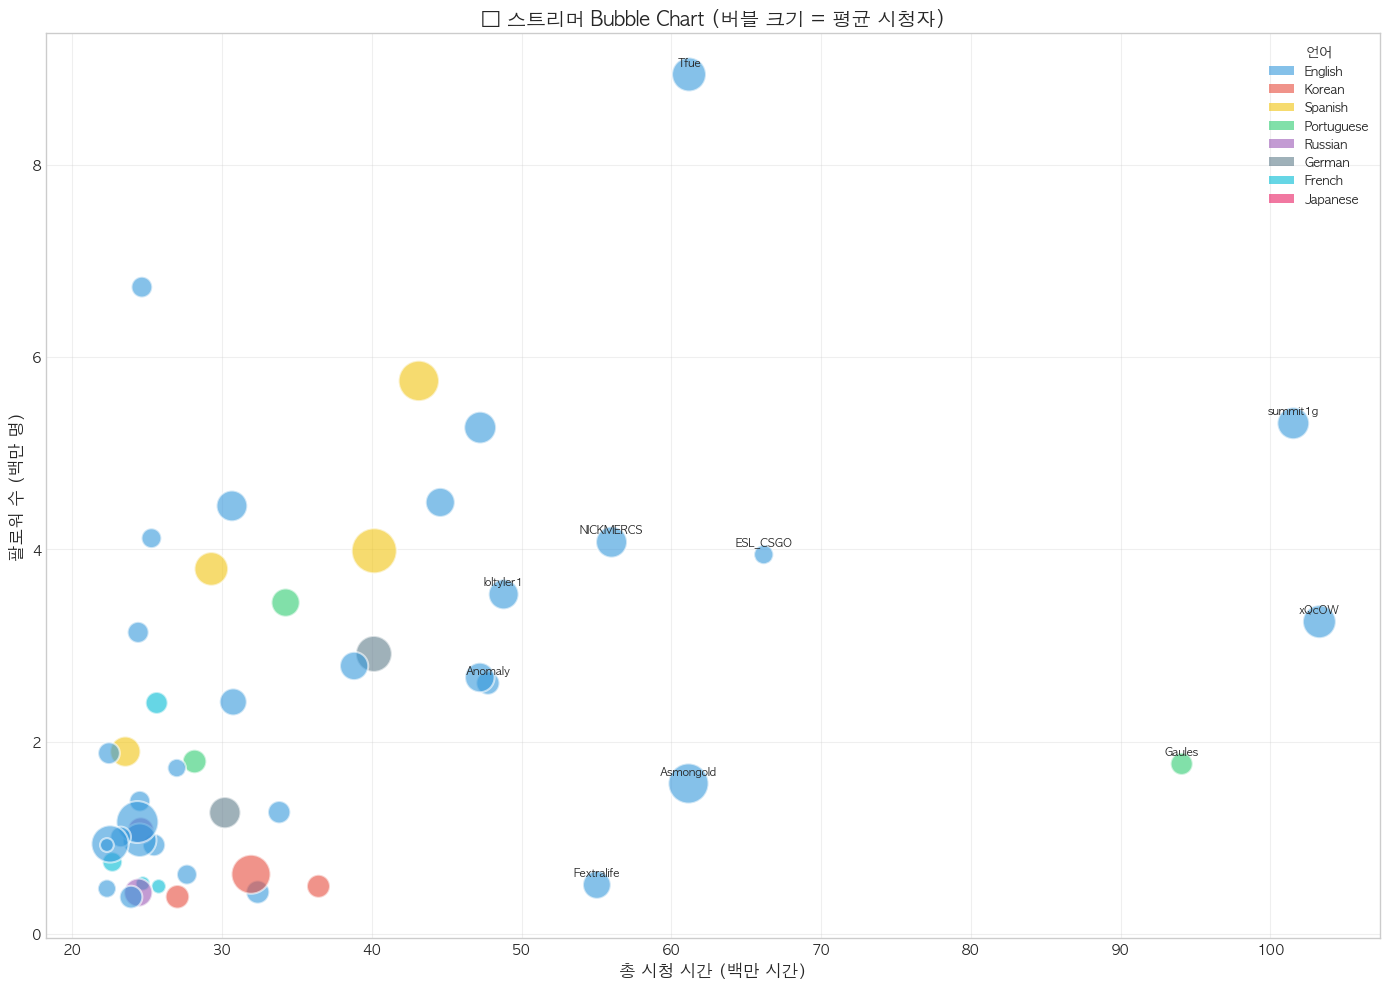

In [18]:
# ============================================
# 시각화: Bubble Chart - 스트리머 분석
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

fig, ax = plt.subplots(figsize=(14, 10))

# 상위 50명 스트리머
top_50_streamers = twitch_streamers.nlargest(50, 'Watch_time_hours').copy()

# 언어별 색상
lang_color_map = {
    'English': '#3498DB', 'Korean': '#E74C3C', 'Spanish': '#F1C40F',
    'Portuguese': '#2ECC71', 'Russian': '#9B59B6', 'German': '#607D8B',
    'French': '#00BCD4', 'Japanese': '#E91E63'
}
colors = [lang_color_map.get(lang, '#95A5A6') for lang in top_50_streamers['Language']]

# 버블 크기 (평균 시청자 기준)
sizes = (top_50_streamers['Avg_viewers'] / top_50_streamers['Avg_viewers'].max()) * 1000 + 50

# 버블 차트
scatter = ax.scatter(
    top_50_streamers['Watch_time_hours'] / 1e6,
    top_50_streamers['Followers'] / 1e6,
    s=sizes,
    c=colors,
    alpha=0.6,
    edgecolors='white',
    linewidth=1.5
)

# 상위 10명 레이블 추가
for idx, row in top_50_streamers.head(10).iterrows():
    ax.annotate(
        row['Channel'],
        (row['Watch_time_hours']/1e6, row['Followers']/1e6),
        fontsize=8,
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points'
    )

ax.set_xlabel('총 시청 시간 (백만 시간)', fontsize=12)
ax.set_ylabel('팔로워 수 (백만 명)', fontsize=12)
ax.set_title('💫 스트리머 Bubble Chart (버블 크기 = 평균 시청자)', fontsize=14, fontweight='bold')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l, alpha=0.6) for l, c in lang_color_map.items()]
ax.legend(handles=legend_elements, loc='upper right', title='언어', fontsize=9)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/14_bubble_chart_streamers.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### 📊 Lollipop Chart - 게임별 성장률

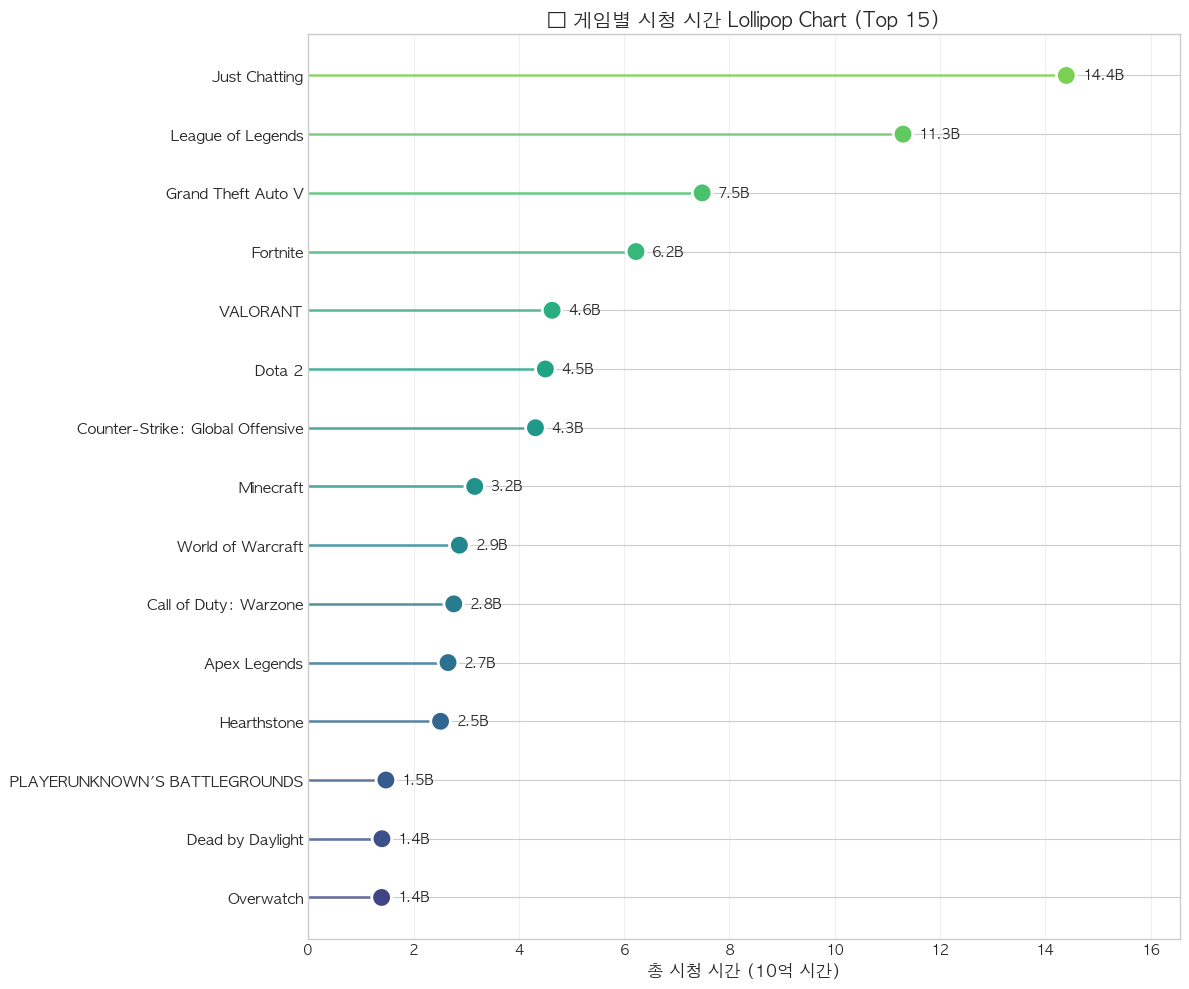

In [19]:
# ============================================
# 시각화: Lollipop Chart - 게임별 시청시간 순위
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

fig, ax = plt.subplots(figsize=(12, 10))

# 상위 15개 게임
top_15 = game_total.nlargest(15, 'Hours_watched').copy()
top_15 = top_15.sort_values('Hours_watched', ascending=True)
top_15['Hours_B'] = top_15['Hours_watched'] / 1e9

# 색상 그라데이션
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top_15)))

# 수평선 그리기
ax.hlines(y=range(len(top_15)), xmin=0, xmax=top_15['Hours_B'], 
          color=colors, alpha=0.7, linewidth=2)

# 원 그리기 (롤리팝 머리)
ax.scatter(top_15['Hours_B'], range(len(top_15)), 
           color=colors, s=200, zorder=3, edgecolors='white', linewidth=2)

# 값 레이블
for idx, (hours, game) in enumerate(zip(top_15['Hours_B'], top_15['Game'])):
    ax.text(hours + 0.3, idx, f'{hours:.1f}B', va='center', fontsize=10, fontweight='bold')

ax.set_yticks(range(len(top_15)))
ax.set_yticklabels(top_15['Game'], fontsize=11)
ax.set_xlabel('총 시청 시간 (10억 시간)', fontsize=12)
ax.set_title('🍭 게임별 시청 시간 Lollipop Chart (Top 15)', fontsize=14, fontweight='bold')
ax.set_xlim(0, top_15['Hours_B'].max() * 1.15)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('output/15_lollipop_chart_games.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### 📊 Stacked Area Chart - 연도별 상위 게임 시청 시간 추이

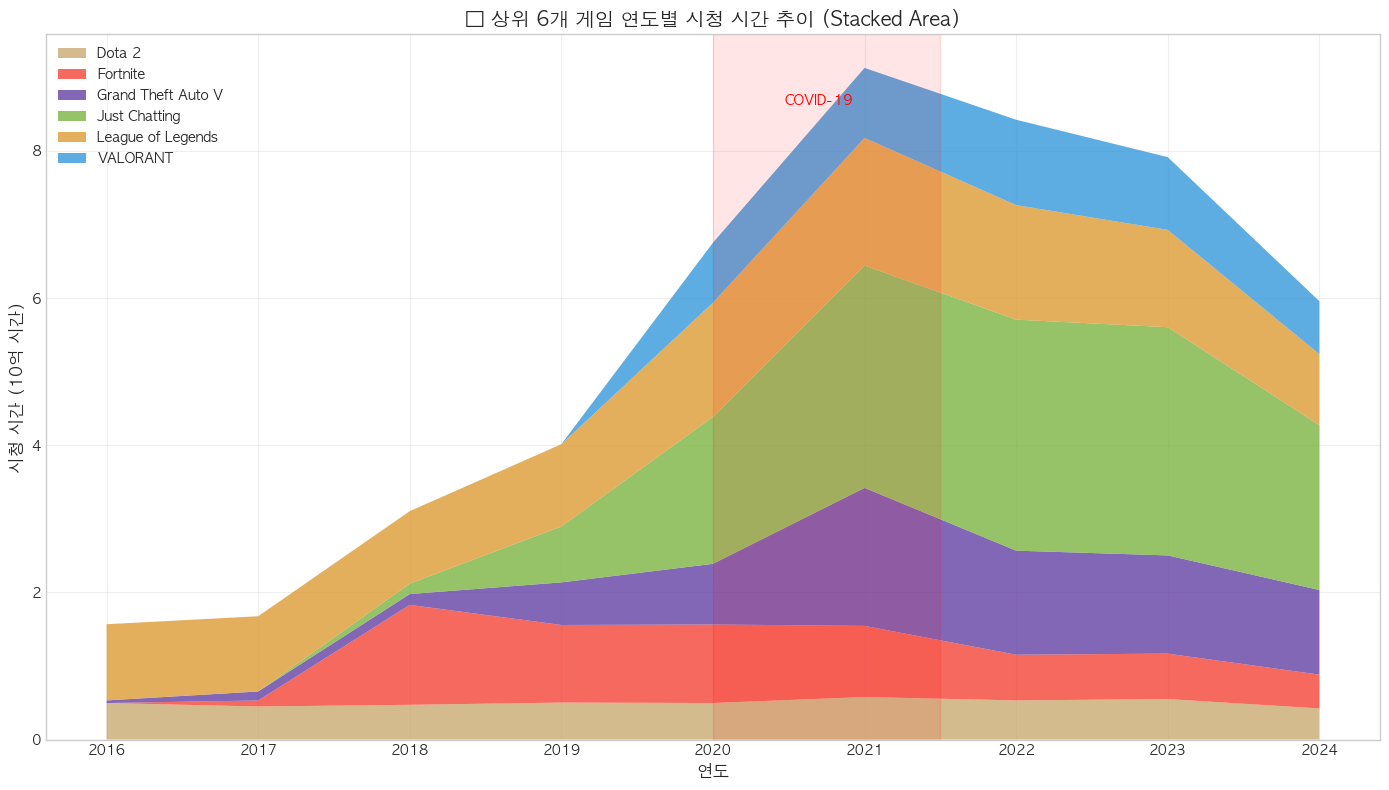

In [20]:
# ============================================
# 시각화: Stacked Area Chart - 연도별 상위 게임 시청 시간
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

fig, ax = plt.subplots(figsize=(14, 8))

# 상위 6개 게임 선택
top_6_games = game_total.nlargest(6, 'Hours_watched')['Game'].tolist()

# 연도별 게임별 시청 시간 피벗
yearly_game = twitch_games[twitch_games['Game'].isin(top_6_games)].groupby(
    ['Year', 'Game'])['Hours_watched'].sum().unstack().fillna(0) / 1e9

# 색상 설정
stack_colors = ['#C9AA71', '#F44336', '#6441A5', '#7CB342', '#DE9B35', '#3498DB']

# Stacked Area Chart
ax.stackplot(yearly_game.index, yearly_game.T, labels=yearly_game.columns, 
             colors=stack_colors, alpha=0.8)

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('시청 시간 (10억 시간)', fontsize=12)
ax.set_title('📊 상위 6개 게임 연도별 시청 시간 추이 (Stacked Area)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# COVID-19 표시
ax.axvspan(2020, 2021.5, alpha=0.1, color='red')
ax.annotate('COVID-19', xy=(2020.7, ax.get_ylim()[1]*0.9), fontsize=10, ha='center', color='red')

plt.tight_layout()
plt.savefig('output/16_stacked_area_games.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

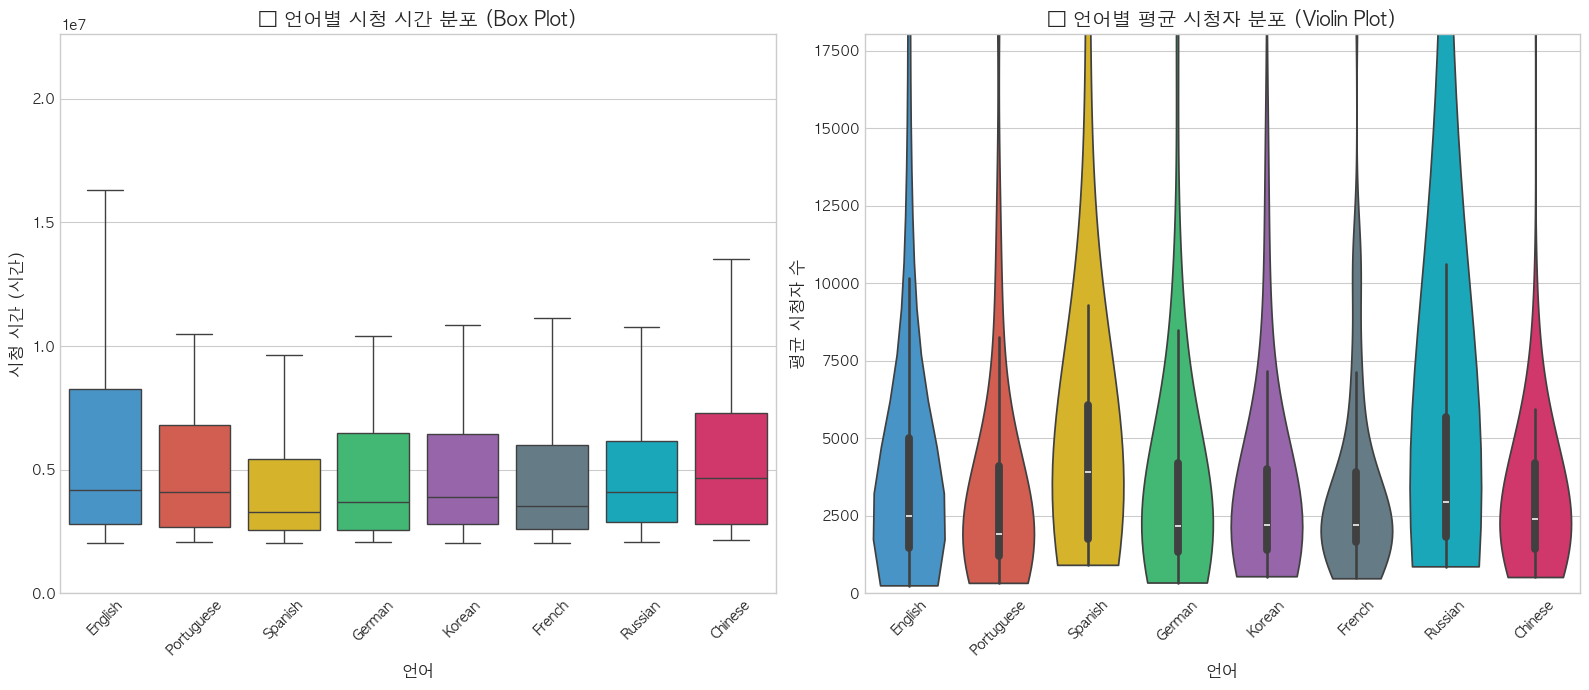

✅ Box Plot & Violin Plot 생성 완료!


In [24]:
# ============================================
# 시각화: Box Plot & Violin Plot - 언어별 분포
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 상위 8개 언어만 필터링
top_languages = twitch_streamers['Language'].value_counts().head(8).index.tolist()
filtered_streamers = twitch_streamers[twitch_streamers['Language'].isin(top_languages)].copy()

# 색상 팔레트 (리스트 형태로 변경)
palette_list = ['#3498DB', '#E74C3C', '#F1C40F', '#2ECC71', '#9B59B6', '#607D8B', '#00BCD4', '#E91E63']

# Box Plot (왼쪽) - hue 파라미터 추가로 palette 사용
sns.boxplot(
    data=filtered_streamers, 
    x='Language', 
    y='Watch_time_hours',
    hue='Language',
    palette=palette_list,
    ax=axes[0],
    showfliers=False,  # 이상치 제외
    legend=False
)
axes[0].set_xlabel('언어', fontsize=12)
axes[0].set_ylabel('시청 시간 (시간)', fontsize=12)
axes[0].set_title('📦 언어별 시청 시간 분포 (Box Plot)', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, filtered_streamers['Watch_time_hours'].quantile(0.95))

# Violin Plot (오른쪽) - hue 파라미터 추가로 palette 사용
sns.violinplot(
    data=filtered_streamers, 
    x='Language', 
    y='Avg_viewers',
    hue='Language',
    palette=palette_list,
    ax=axes[1],
    cut=0,
    legend=False
)
axes[1].set_xlabel('언어', fontsize=12)
axes[1].set_ylabel('평균 시청자 수', fontsize=12)
axes[1].set_title('🎻 언어별 평균 시청자 분포 (Violin Plot)', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, filtered_streamers['Avg_viewers'].quantile(0.95))

plt.tight_layout()
plt.savefig('output/17_boxplot_violinplot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print('✅ Box Plot & Violin Plot 생성 완료!')

In [23]:
# # ============================================
# # 시각화: Box Plot & Violin Plot - 언어별 분포
# # ============================================
# plt.rcParams['font.family'] = 'AppleGothic'

# fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# # 상위 8개 언어만 필터링
# top_languages = twitch_streamers['Language'].value_counts().head(8).index.tolist()
# filtered_streamers = twitch_streamers[twitch_streamers['Language'].isin(top_languages)]

# # 색상 팔레트
# palette = {
#     'English': '#3498DB', 'Korean': '#E74C3C', 'Spanish': '#F1C40F',
#     'Portuguese': '#2ECC71', 'Russian': '#9B59B6', 'German': '#607D8B',
#     'French': '#00BCD4', 'Japanese': '#E91E63', 'Other': '#95A5A6'
# }

# # Box Plot (왼쪽)
# sns.boxplot(
#     data=filtered_streamers, 
#     x='Language', 
#     y='Watch_time_hours',
#     palette=palette,
#     ax=axes[0],
#     showfliers=False  # 이상치 제외
# )
# axes[0].set_xlabel('언어', fontsize=12)
# axes[0].set_ylabel('시청 시간 (시간)', fontsize=12)
# axes[0].set_title('📦 언어별 시청 시간 분포 (Box Plot)', fontsize=14, fontweight='bold')
# axes[0].tick_params(axis='x', rotation=45)
# axes[0].set_ylim(0, filtered_streamers['Watch_time_hours'].quantile(0.95))

# # Violin Plot (오른쪽)
# sns.violinplot(
#     data=filtered_streamers, 
#     x='Language', 
#     y='Avg_viewers',
#     palette=palette,
#     ax=axes[1],
#     cut=0
# )
# axes[1].set_xlabel('언어', fontsize=12)
# axes[1].set_ylabel('평균 시청자 수', fontsize=12)
# axes[1].set_title('🎻 언어별 평균 시청자 분포 (Violin Plot)', fontsize=14, fontweight='bold')
# axes[1].tick_params(axis='x', rotation=45)
# axes[1].set_ylim(0, filtered_streamers['Avg_viewers'].quantile(0.95))

# plt.tight_layout()
# plt.savefig('output/17_boxplot_violinplot.png', dpi=150, bbox_inches='tight', facecolor='white')
# plt.show()

#### 📊 Donut Chart - 게임 카테고리별 점유율

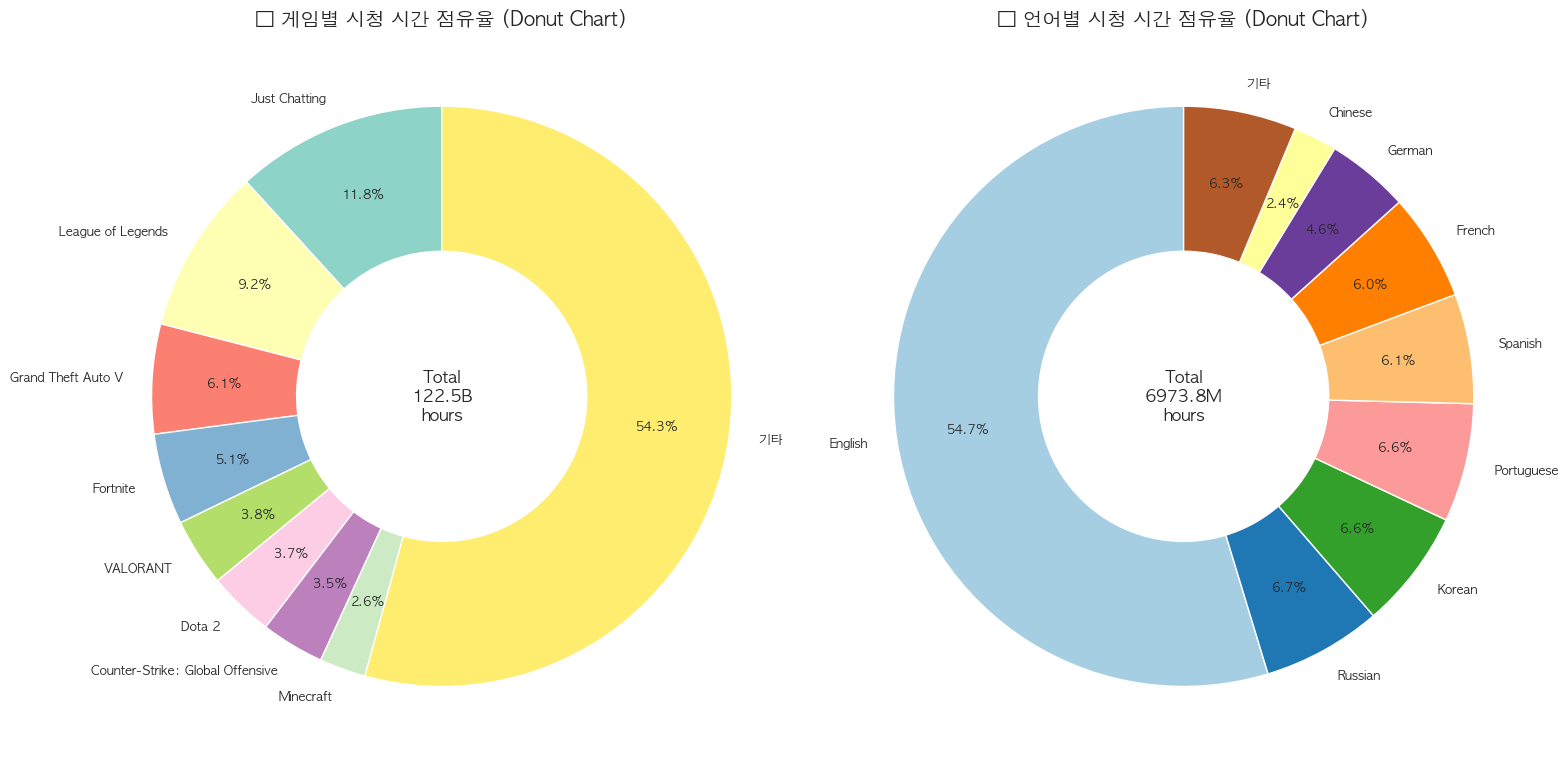

In [25]:
# ============================================
# 시각화: Donut Chart - 상위 게임 점유율
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 상위 8개 게임 + 기타
top_8 = game_total.nlargest(8, 'Hours_watched').copy()
others_hours = game_total.nsmallest(len(game_total)-8, 'Hours_watched')['Hours_watched'].sum()
donut_data = pd.concat([
    top_8[['Game', 'Hours_watched']],
    pd.DataFrame({'Game': ['기타'], 'Hours_watched': [others_hours]})
], ignore_index=True)

# 색상
donut_colors = plt.cm.Set3(np.linspace(0, 1, len(donut_data)))

# 왼쪽: 시청 시간 Donut
wedges, texts, autotexts = axes[0].pie(
    donut_data['Hours_watched'],
    labels=donut_data['Game'],
    autopct='%1.1f%%',
    colors=donut_colors,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    pctdistance=0.75,
    startangle=90,
    textprops={'fontsize': 9}
)

# 중앙에 텍스트
centre_circle = plt.Circle((0, 0), 0.35, fc='white')
axes[0].add_patch(centre_circle)
axes[0].text(0, 0, f'Total\n{game_total["Hours_watched"].sum()/1e9:.1f}B\nhours', 
             ha='center', va='center', fontsize=12, fontweight='bold')
axes[0].set_title('🍩 게임별 시청 시간 점유율 (Donut Chart)', fontsize=14, fontweight='bold')

# 오른쪽: 언어별 Donut
lang_data = language_stats.head(8).copy()
others_lang = language_stats.iloc[8:]['Total_Watch_Time'].sum()
lang_donut = pd.concat([
    lang_data[['Language', 'Total_Watch_Time']],
    pd.DataFrame({'Language': ['기타'], 'Total_Watch_Time': [others_lang]})
], ignore_index=True)

lang_colors = plt.cm.Paired(np.linspace(0, 1, len(lang_donut)))

wedges2, texts2, autotexts2 = axes[1].pie(
    lang_donut['Total_Watch_Time'],
    labels=lang_donut['Language'],
    autopct='%1.1f%%',
    colors=lang_colors,
    wedgeprops=dict(width=0.5, edgecolor='white'),
    pctdistance=0.75,
    startangle=90,
    textprops={'fontsize': 9}
)

centre_circle2 = plt.Circle((0, 0), 0.35, fc='white')
axes[1].add_patch(centre_circle2)
axes[1].text(0, 0, f'Total\n{language_stats["Total_Watch_Time"].sum()/1e6:.1f}M\nhours', 
             ha='center', va='center', fontsize=12, fontweight='bold')
axes[1].set_title('🍩 언어별 시청 시간 점유율 (Donut Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/18_donut_charts.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### 📊 Waterfall Chart - 연도별 시청 시간 변화량

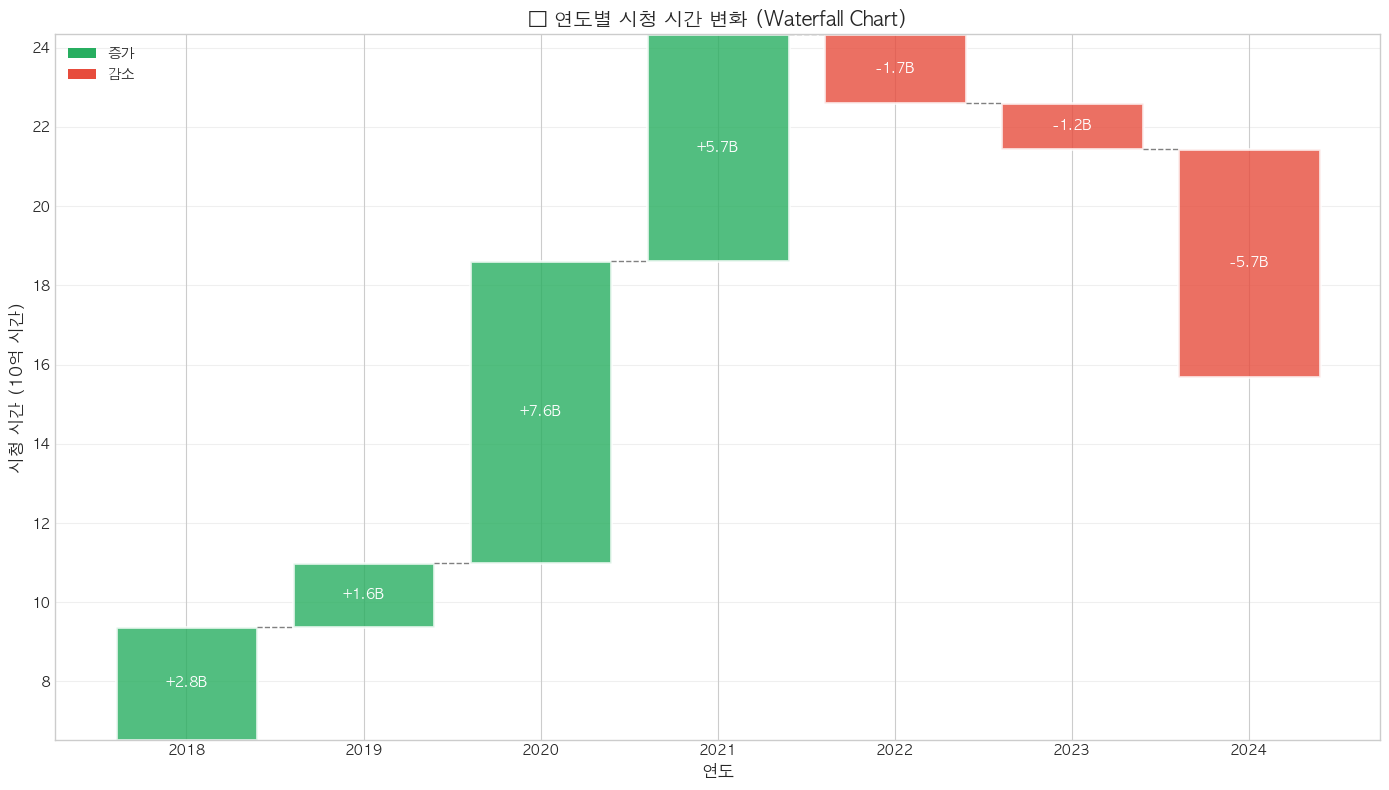

In [26]:
# ============================================
# 시각화: Waterfall Chart - 연도별 시청 시간 변화량
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'

fig, ax = plt.subplots(figsize=(14, 8))

# 연도별 변화량 계산
waterfall_data = yearly_total.copy()
waterfall_data['Change'] = waterfall_data['Hours_watched'].diff()
waterfall_data = waterfall_data.dropna()
waterfall_data['Change_B'] = waterfall_data['Change'] / 1e9

# 누적값 계산
waterfall_data['Cumsum'] = waterfall_data['Hours_watched'].shift(1) / 1e9
waterfall_data = waterfall_data.dropna()

# 막대 색상 (증가: 녹색, 감소: 빨간색)
colors = ['#27AE60' if c > 0 else '#E74C3C' for c in waterfall_data['Change_B']]

# 막대 그리기
bars = ax.bar(
    waterfall_data['Year'].astype(str),
    waterfall_data['Change_B'],
    bottom=waterfall_data['Cumsum'],
    color=colors,
    edgecolor='white',
    linewidth=2,
    alpha=0.8
)

# 연결선 그리기
for i in range(len(waterfall_data) - 1):
    current_top = waterfall_data.iloc[i]['Cumsum'] + waterfall_data.iloc[i]['Change_B']
    ax.hlines(current_top, i + 0.4, i + 0.6, colors='gray', linewidth=1, linestyles='dashed')

# 값 레이블
for i, (idx, row) in enumerate(waterfall_data.iterrows()):
    change = row['Change_B']
    y_pos = row['Cumsum'] + change/2
    label = f'+{change:.1f}B' if change > 0 else f'{change:.1f}B'
    ax.text(i, y_pos, label, ha='center', va='center', fontsize=10, fontweight='bold',
            color='white' if abs(change) > 1 else 'black')

ax.set_xlabel('연도', fontsize=12)
ax.set_ylabel('시청 시간 (10억 시간)', fontsize=12)
ax.set_title('💧 연도별 시청 시간 변화 (Waterfall Chart)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#27AE60', label='증가'),
                   Patch(facecolor='#E74C3C', label='감소')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('output/19_waterfall_chart.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

#### 📊 Interactive Visualizations (Plotly)

Plotly를 사용한 인터랙티브 시각화입니다. 마우스 호버, 줌, 필터링 등이 가능합니다.

In [27]:
# ============================================
# Interactive: Sunburst Chart - 계층적 구조 시각화
# ============================================
if PLOTLY_AVAILABLE:
    # 상위 10개 게임의 연도별 데이터
    top_10_names = game_total.nlargest(10, 'Hours_watched')['Game'].tolist()
    sunburst_data = twitch_games[twitch_games['Game'].isin(top_10_names)].copy()
    sunburst_data['Hours_B'] = sunburst_data['Hours_watched'] / 1e9
    
    # Sunburst 데이터 준비
    sunburst_agg = sunburst_data.groupby(['Game', 'Year'])['Hours_B'].sum().reset_index()
    
    fig = px.sunburst(
        sunburst_agg,
        path=['Game', 'Year'],
        values='Hours_B',
        color='Hours_B',
        color_continuous_scale='Viridis',
        title='🌞 게임별 연도별 시청 시간 Sunburst Chart'
    )
    
    fig.update_layout(
        width=800,
        height=800,
        font=dict(size=12)
    )
    
    fig.show()
    fig.write_html('output/20_sunburst_interactive.html')
    print('✅ output/20_sunburst_interactive.html 저장 완료!')
else:
    print('⚠️ Plotly가 설치되지 않았습니다. pip install plotly 실행 후 다시 시도하세요.')

✅ output/20_sunburst_interactive.html 저장 완료!


In [28]:
# ============================================
# Interactive: Scatter Plot - 스트리머 분석
# ============================================
if PLOTLY_AVAILABLE:
    top_100_streamers = twitch_streamers.nlargest(100, 'Watch_time_hours').copy()
    
    fig = px.scatter(
        top_100_streamers,
        x='Watch_time_hours',
        y='Followers',
        size='Avg_viewers',
        color='Language',
        hover_name='Channel',
        hover_data=['Peak_viewers', 'Partnered'],
        title='💫 스트리머 Interactive Scatter Plot (시청시간 vs 팔로워)',
        labels={
            'Watch_time_hours': '총 시청 시간 (시간)',
            'Followers': '팔로워 수',
            'Avg_viewers': '평균 시청자',
            'Language': '언어'
        },
        color_discrete_sequence=px.colors.qualitative.Set2
    )
    
    fig.update_layout(
        width=1000,
        height=700,
        font=dict(size=12)
    )
    
    fig.show()
    fig.write_html('output/21_scatter_interactive.html')
    print('✅ output/21_scatter_interactive.html 저장 완료!')
else:
    print('⚠️ Plotly가 설치되지 않았습니다.')

✅ output/21_scatter_interactive.html 저장 완료!


In [29]:
# ============================================
# Interactive: Animated Bar Chart - 연도별 게임 순위 변화
# ============================================
if PLOTLY_AVAILABLE:
    # 상위 10개 게임 필터링
    top_games_animation = game_total.nlargest(10, 'Hours_watched')['Game'].tolist()
    anim_data = twitch_games[twitch_games['Game'].isin(top_games_animation)].copy()
    anim_data['Hours_B'] = anim_data['Hours_watched'] / 1e9
    
    # 연도별 집계
    anim_yearly = anim_data.groupby(['Year', 'Game'])['Hours_B'].sum().reset_index()
    
    fig = px.bar(
        anim_yearly,
        x='Hours_B',
        y='Game',
        color='Game',
        orientation='h',
        animation_frame='Year',
        range_x=[0, anim_yearly['Hours_B'].max() * 1.1],
        title='🎬 연도별 게임 시청 시간 변화 (Animated Bar Chart)',
        labels={'Hours_B': '시청 시간 (10억 시간)', 'Game': '게임'},
        color_discrete_sequence=px.colors.qualitative.Bold
    )
    
    fig.update_layout(
        width=900,
        height=600,
        showlegend=False,
        yaxis={'categoryorder': 'total ascending'}
    )
    
    fig.show()
    fig.write_html('output/22_animated_bar_chart.html')
    print('✅ output/22_animated_bar_chart.html 저장 완료!')
else:
    print('⚠️ Plotly가 설치되지 않았습니다.')

✅ output/22_animated_bar_chart.html 저장 완료!


In [30]:
# ============================================
# Interactive: Treemap (Plotly)
# ============================================
if PLOTLY_AVAILABLE:
    # 상위 20개 게임
    treemap_data = game_total.nlargest(20, 'Hours_watched').copy()
    treemap_data['Hours_B'] = treemap_data['Hours_watched'] / 1e9
    
    fig = px.treemap(
        treemap_data,
        path=['Game'],
        values='Hours_B',
        color='Avg_viewers',
        color_continuous_scale='RdYlGn',
        title='🌳 게임별 시청 시간 Interactive Treemap (색상 = 평균 시청자)',
        hover_data=['Peak_viewers', 'Streamers']
    )
    
    fig.update_layout(
        width=900,
        height=700,
        font=dict(size=14)
    )
    
    fig.show()
    fig.write_html('output/23_treemap_interactive.html')
    print('✅ output/23_treemap_interactive.html 저장 완료!')
else:
    print('⚠️ Plotly가 설치되지 않았습니다.')

✅ output/23_treemap_interactive.html 저장 완료!


In [31]:
# ============================================
# Interactive: Polar Bar Chart - 월별 시청 패턴
# ============================================
if PLOTLY_AVAILABLE:
    monthly_pattern = twitch_games.groupby('Month')['Hours_watched'].mean().reset_index()
    monthly_pattern['Hours_B'] = monthly_pattern['Hours_watched'] / 1e9
    monthly_pattern['Month_Name'] = ['1월', '2월', '3월', '4월', '5월', '6월',
                                      '7월', '8월', '9월', '10월', '11월', '12월']
    
    fig = px.bar_polar(
        monthly_pattern,
        r='Hours_B',
        theta='Month_Name',
        color='Hours_B',
        color_continuous_scale='Plasma',
        title='🎯 월별 평균 시청 시간 Polar Bar Chart'
    )
    
    fig.update_layout(
        width=700,
        height=700,
        font=dict(size=12),
        polar=dict(
            radialaxis=dict(showticklabels=True, ticksuffix='B')
        )
    )
    
    fig.show()
    fig.write_html('output/24_polar_bar_chart.html')
    print('✅ output/24_polar_bar_chart.html 저장 완료!')
else:
    print('⚠️ Plotly가 설치되지 않았습니다.')

✅ output/24_polar_bar_chart.html 저장 완료!


---

### 📋 시각화 방법 요약

| 번호 | 시각화 유형 | 설명 | 라이브러리 |
|------|------------|------|-----------|
| 1 | Area Chart | 연도별 시청 시간 추이 | Matplotlib |
| 2 | Bar Chart | 연간 성장률 | Matplotlib |
| 3 | Horizontal Bar | 게임별 시청 시간 Top 15 | Matplotlib |
| 4 | Pie Chart | 게임별 점유율 | Matplotlib |
| 5 | Line Chart | 상위 게임 연도별 추이 | Matplotlib |
| 6 | Heatmap | 게임별 월평균 시청 시간 | Seaborn |
| 7 | **Treemap** | 게임별 계층 구조 | Squarify |
| 8 | **Radar Chart** | 게임별 다차원 비교 | Matplotlib |
| 9 | **Bubble Chart** | 스트리머 3차원 분석 | Matplotlib |
| 10 | **Lollipop Chart** | 게임별 순위 시각화 | Matplotlib |
| 11 | **Stacked Area** | 상위 게임 누적 추이 | Matplotlib |
| 12 | **Box Plot** | 언어별 시청 시간 분포 | Seaborn |
| 13 | **Violin Plot** | 언어별 시청자 분포 | Seaborn |
| 14 | **Donut Chart** | 점유율 (중앙 비움) | Matplotlib |
| 15 | **Waterfall Chart** | 연도별 변화량 | Matplotlib |
| 16 | **Sunburst (Interactive)** | 계층적 드릴다운 | Plotly |
| 17 | **Scatter (Interactive)** | 스트리머 상관관계 | Plotly |
| 18 | **Animated Bar** | 연도별 순위 변화 | Plotly |
| 19 | **Treemap (Interactive)** | 게임별 구조 | Plotly |
| 20 | **Polar Bar** | 월별 패턴 | Plotly |

---

### 📦 필요 라이브러리 설치

```bash
pip install pandas numpy matplotlib seaborn squarify plotly
```

### 4.6 종합 대시보드

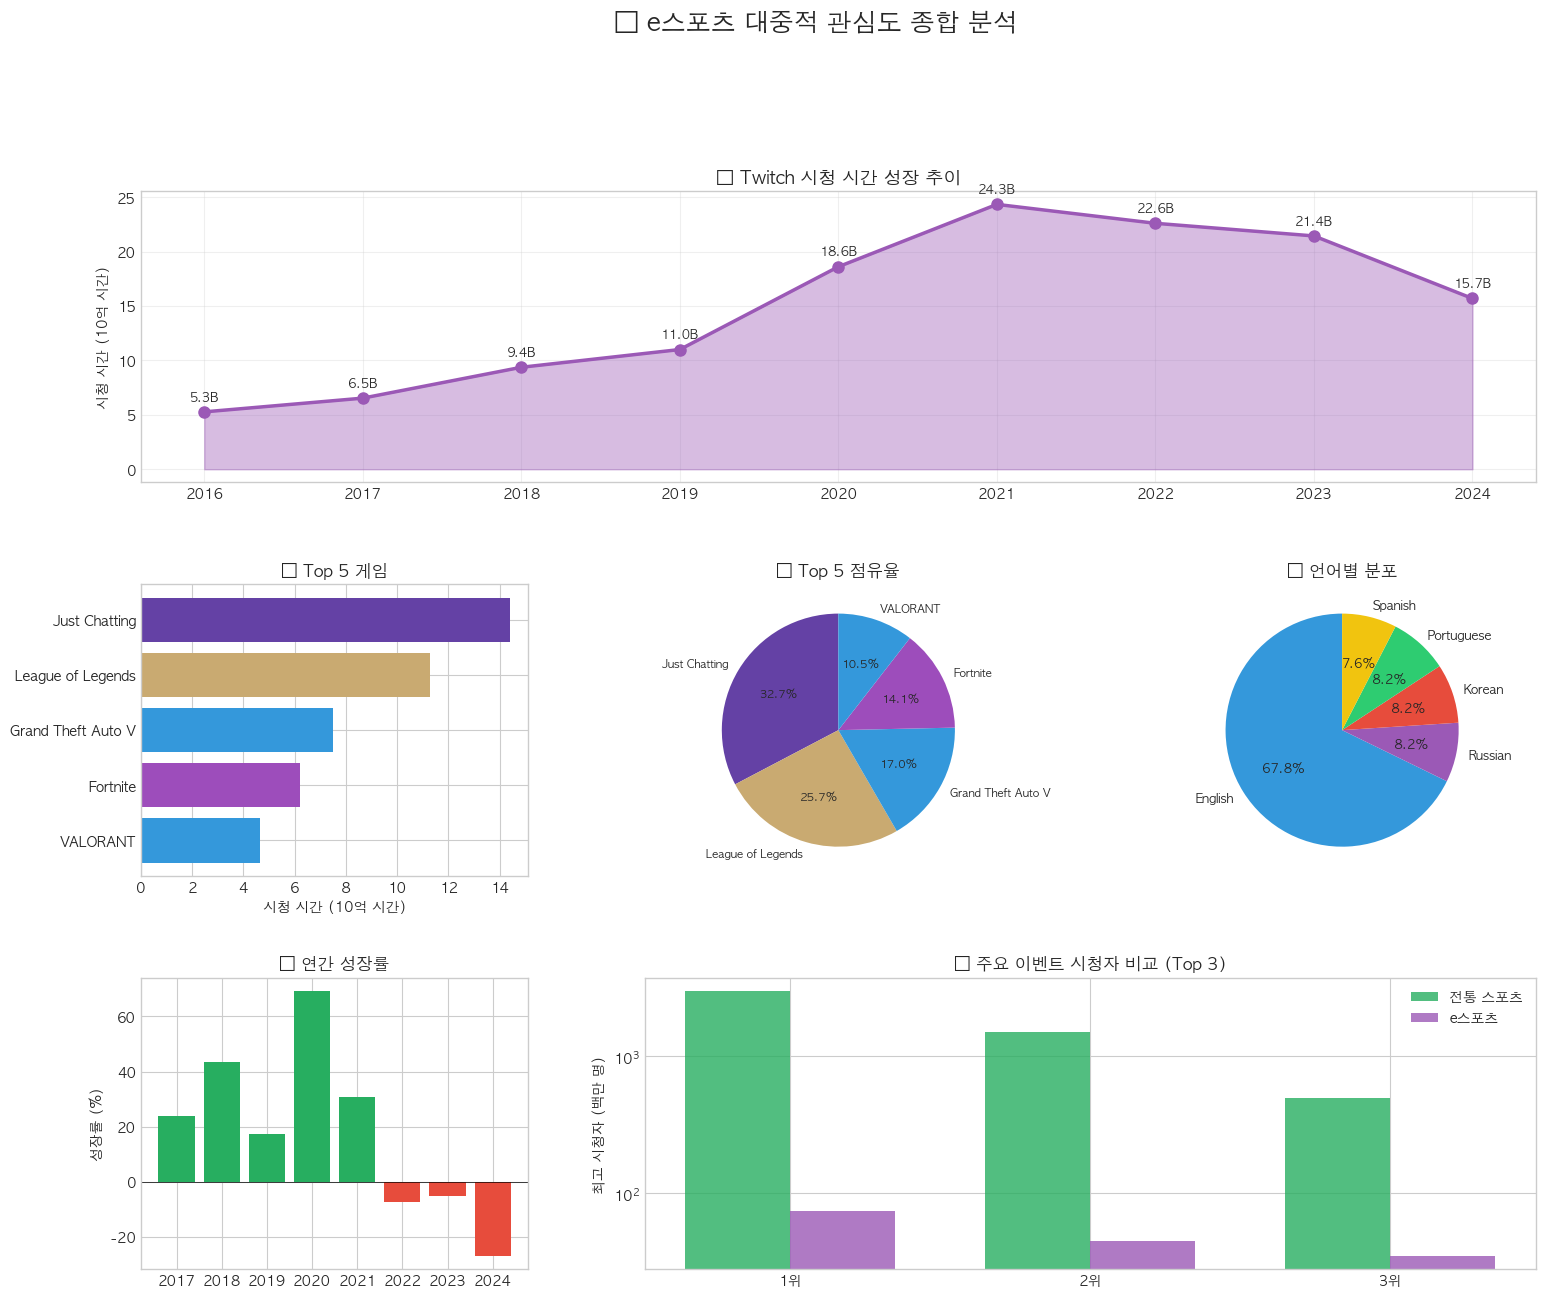

In [32]:
# ============================================
# 시각화 8: 종합 대시보드
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig = plt.figure(figsize=(18, 14))

# 레이아웃 설정
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. 연도별 성장 추이 (상단 전체)
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(yearly_total['Year'], yearly_total['Hours_watched']/1e9, 
                 alpha=0.4, color=COLORS['esports'])
ax1.plot(yearly_total['Year'], yearly_total['Hours_watched']/1e9, 
         marker='o', linewidth=2.5, markersize=8, color=COLORS['esports'])
ax1.set_ylabel('시청 시간 (10억 시간)')
ax1.set_title('📈 Twitch 시청 시간 성장 추이', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
for x, y in zip(yearly_total['Year'], yearly_total['Hours_watched']/1e9):
    ax1.annotate(f'{y:.1f}B', (x, y), textcoords='offset points', 
                 xytext=(0, 8), ha='center', fontsize=9)

# 2. 게임별 시청 시간 (중단 왼쪽)
ax2 = fig.add_subplot(gs[1, 0])
top5 = game_total.nlargest(5, 'Hours_watched')
colors_top5 = [COLORS.get(g, '#3498DB') for g in top5['Game']]
ax2.barh(top5['Game'], top5['Hours_watched']/1e9, color=colors_top5)
ax2.set_xlabel('시청 시간 (10억 시간)')
ax2.set_title('🎮 Top 5 게임', fontsize=12, fontweight='bold')
ax2.invert_yaxis()

# 3. 게임별 점유율 (중단 중앙)
ax3 = fig.add_subplot(gs[1, 1])
ax3.pie(top5['Hours_watched'], labels=top5['Game'], autopct='%1.1f%%',
        colors=colors_top5, startangle=90, textprops={'fontsize': 8})
ax3.set_title('📊 Top 5 점유율', fontsize=12, fontweight='bold')

# 4. 언어별 분포 (중단 오른쪽)
ax4 = fig.add_subplot(gs[1, 2])
lang_top5 = language_stats.head(5)
lang_colors_pie = [COLORS.get(l, '#95A5A6') for l in lang_top5['Language']]
ax4.pie(lang_top5['Total_Watch_Time'], labels=lang_top5['Language'],
        autopct='%1.1f%%', colors=lang_colors_pie, startangle=90, textprops={'fontsize': 9})
ax4.set_title('🌍 언어별 분포', fontsize=12, fontweight='bold')

# 5. 성장률 비교 (하단 왼쪽)
ax5 = fig.add_subplot(gs[2, 0])
growth_valid_plot = yearly_total.dropna(subset=['Growth_rate'])
growth_colors = ['#27AE60' if x > 0 else '#E74C3C' for x in growth_valid_plot['Growth_rate']]
ax5.bar(growth_valid_plot['Year'], growth_valid_plot['Growth_rate'], color=growth_colors)
ax5.axhline(y=0, color='black', linewidth=0.5)
ax5.set_ylabel('성장률 (%)')
ax5.set_title('📊 연간 성장률', fontsize=12, fontweight='bold')

# 6. 전통 스포츠 비교 (하단 중앙-오른쪽)
ax6 = fig.add_subplot(gs[2, 1:])
esports_events = traditional_sports[traditional_sports['Type'] == 'Esports'].nlargest(3, 'Peak_Viewers_Million')
trad_events = traditional_sports[traditional_sports['Type'] == 'Traditional'].nlargest(3, 'Peak_Viewers_Million')

x = range(3)
width = 0.35
ax6.bar([i - width/2 for i in x], trad_events['Peak_Viewers_Million'], width, 
        label='전통 스포츠', color='#27AE60', alpha=0.8)
ax6.bar([i + width/2 for i in x], esports_events['Peak_Viewers_Million'], width,
        label='e스포츠', color='#9B59B6', alpha=0.8)
ax6.set_ylabel('최고 시청자 (백만 명)')
ax6.set_title('🏆 주요 이벤트 시청자 비교 (Top 3)', fontsize=12, fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels(['1위', '2위', '3위'])
ax6.legend()
ax6.set_yscale('log')

plt.suptitle('📺 e스포츠 대중적 관심도 종합 분석', fontsize=18, fontweight='bold', y=1.01)
plt.savefig('output/08_comprehensive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---

## 5️⃣ 분석 결과 요약

In [33]:
# ============================================
# 최종 비교 테이블
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac


# 데이터 기반 주요 지표 계산
last_year = yearly_total['Year'].max()
first_year = yearly_total['Year'].min()
last_year_hours = yearly_total[yearly_total['Year']==last_year]['Hours_watched'].values[0]
avg_growth = yearly_total['Growth_rate'].mean()
top_game = game_total.iloc[0]['Game']
top_language = language_stats.iloc[0]['Language']

# e스포츠 주요 지표
esports_stats = {
    f'총 시청 시간 ({last_year}년)': format_hours(last_year_hours),
    '평균 연간 성장률': f"{avg_growth:.1f}%",
    '최고 성장률': f"{yearly_total['Growth_rate'].max():.1f}%",
    '인기 게임 1위': top_game,
    '주요 언어': top_language,
    '분석 스트리머 수': f"{len(twitch_streamers):,}명",
    '분석 게임 수': f"{twitch_games['Game'].nunique():,}개",
    '최대 이벤트 시청자': f"{traditional_sports[traditional_sports['Type']=='Esports']['Peak_Viewers_Million'].max()}M"
}

print('='*70)
print('📊 대중적 관심도 분석 최종 요약')
print('='*70)

for key, value in esports_stats.items():
    print(f"   {key}: {value}")

print('\n' + '='*70)
print('📈 전통 스포츠 대비 e스포츠 비교')
print('='*70)

comparison_table = pd.DataFrame({
    '지표': ['최대 이벤트 시청자', '평균 이벤트 시청자', 'Twitch 성장률', '글로벌 접근성'],
    '전통 스포츠': ['3,000M (올림픽)', '763M', '3-5%', '지역 제한적'],
    'e스포츠': ['75M (LoL Worlds)', '44.5M', f"{avg_growth:.1f}%", '글로벌 무제한'],
    '비율': ['2.5%', '5.8%', f"{avg_growth/4:.1f}배", '-']
})

display(comparison_table.set_index('지표'))

📊 대중적 관심도 분석 최종 요약
   총 시청 시간 (2024년): 15.7B hours
   평균 연간 성장률: 18.2%
   최고 성장률: 69.2%
   인기 게임 1위: Just Chatting
   주요 언어: English
   분석 스트리머 수: 1,000명
   분석 게임 수: 2,359개
   최대 이벤트 시청자: 75M

📈 전통 스포츠 대비 e스포츠 비교


,전통 스포츠,e스포츠,비율
지표,,,
최대 이벤트 시청자,"3,000M (올림픽)",75M (LoL Worlds),2.5%
평균 이벤트 시청자,763M,44.5M,5.8%
Twitch 성장률,3-5%,18.2%,4.6배
글로벌 접근성,지역 제한적,글로벌 무제한,-


---

# 📚 Part 2: 데이터 수집 가이드

---

## 📌 수집 가능한 데이터 소스

| 플랫폼 | 수집 방법 | API 키 필요 | 측정 지표 | 난이도 |
|--------|----------|------------|----------|--------|
| **Google Trends** | pytrends | ❌ 불필요 | 검색량 추이 | ⭐ 쉬움 |
| **Wikipedia** | REST API | ❌ 불필요 | 페이지 조회수 | ⭐ 쉬움 |
| **웹 크롤링** | BeautifulSoup | ❌ 불필요 | 다양함 | ⭐⭐ 보통 |
| **YouTube** | YouTube Data API | ✅ 필요 | 조회수, 구독자 | ⭐⭐ 보통 |
| **Reddit** | PRAW (API) | ✅ 필요 | 게시물, 댓글 수 | ⭐⭐ 보통 |
| **Twitch** | Twitch API | ✅ 필요 | 시청자 수, 채널 | ⭐⭐ 보통 |

---

## 6️⃣ Google Trends - 검색량 추이 (API 키 불필요 ⭐)

### 📌 특징
- **API 키 불필요** - pytrends 라이브러리로 바로 사용
- 검색어별 상대적 관심도 (0-100 스케일)
- 시간대별, 지역별 비교 가능

In [34]:
# ============================================
# Google Trends 설치 및 설정
# ============================================
# !pip install pytrends

from pytrends.request import TrendReq

# pytrends 객체 생성
pytrends = TrendReq(hl='ko', tz=540)  # 한국어, 한국 시간대

print('✅ pytrends 설정 완료!')

✅ pytrends 설정 완료!


In [35]:
# ============================================
# Google Trends 데이터 수집
# ============================================

# 비교할 검색어 설정 (최대 5개)
keywords = ['League of Legends', 'FIFA', 'NFL', 'Esports', 'World Cup']

# 검색 기간 설정 (최근 5년)
pytrends.build_payload(
    kw_list=keywords,
    cat=0,  # 카테고리 (0: 전체)
    timeframe='today 5-y',  # 최근 5년
    geo='',  # 전세계 (특정 국가: 'KR', 'US' 등)
    gprop=''  # 검색 유형 (웹검색)
)

# 시간별 관심도 데이터 가져오기
trends_data = pytrends.interest_over_time()

print('✅ Google Trends 데이터 수집 완료!')
print(f'   - 기간: {trends_data.index.min()} ~ {trends_data.index.max()}')
print(f'   - 데이터 포인트: {len(trends_data)}개')
display(trends_data.head(10))

✅ Google Trends 데이터 수집 완료!
   - 기간: 2021-01-24 00:00:00 ~ 2026-01-25 00:00:00
   - 데이터 포인트: 262개


,League of Legends,FIFA,NFL,Esports,World Cup,isPartial
date,,,,,,
2021-01-24,0,2,7,0,0,False
2021-01-31,0,2,2,0,0,False
2021-02-07,0,2,4,0,1,False
2021-02-14,0,2,1,0,0,False
2021-02-21,0,2,1,0,0,False
2021-02-28,0,1,1,0,0,False
2021-03-07,0,1,1,0,0,False
2021-03-14,0,1,2,0,0,False
2021-03-21,0,2,1,0,1,False


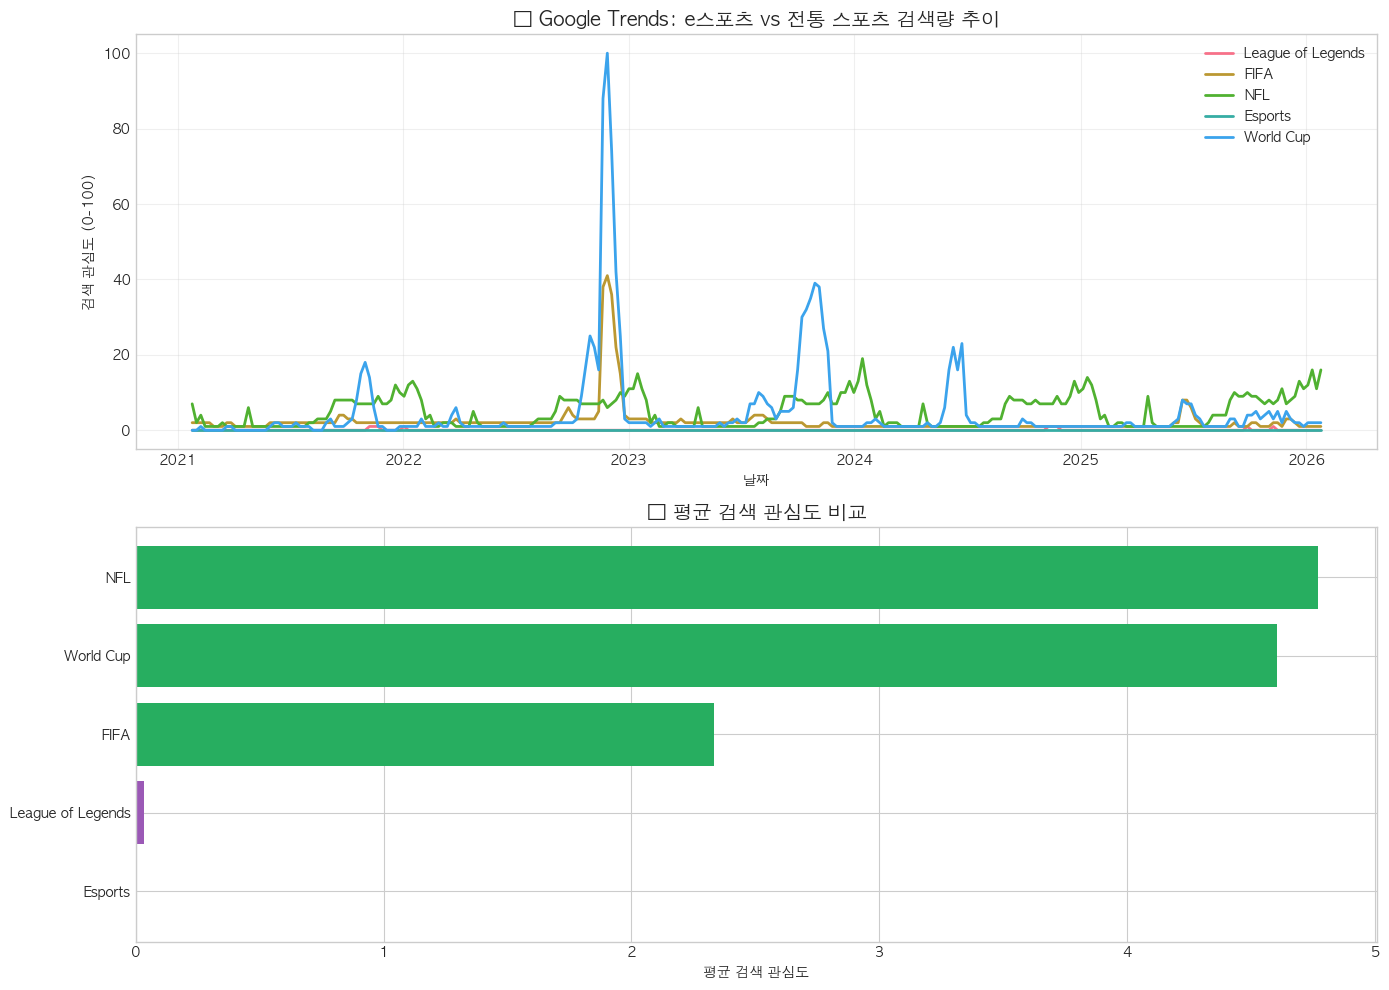

In [36]:
# ============================================
# Google Trends 시각화
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# 1. 시간별 추이
for keyword in keywords:
    if keyword in trends_data.columns:
        axes[0].plot(trends_data.index, trends_data[keyword], label=keyword, linewidth=2)

axes[0].set_xlabel('날짜')
axes[0].set_ylabel('검색 관심도 (0-100)')
axes[0].set_title('📈 Google Trends: e스포츠 vs 전통 스포츠 검색량 추이', fontsize=14, fontweight='bold')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# 2. 평균 관심도 비교
avg_interest = trends_data[keywords].mean().sort_values(ascending=True)
colors = ['#9B59B6' if 'League' in k or 'Esports' in k else '#27AE60' for k in avg_interest.index]
axes[1].barh(avg_interest.index, avg_interest.values, color=colors)
axes[1].set_xlabel('평균 검색 관심도')
axes[1].set_title('📊 평균 검색 관심도 비교', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('output/09_google_trends_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

🇰🇷 한국 검색량 데이터:


,롤,축구,K리그,LCK,프리미어리그,isPartial
date,,,,,,
2025-01-26,69,22,2,9,10,False
2025-02-02,45,18,1,7,7,False
2025-02-09,45,18,2,9,5,False
2025-02-16,46,24,4,8,9,False
2025-02-23,46,22,3,4,8,False


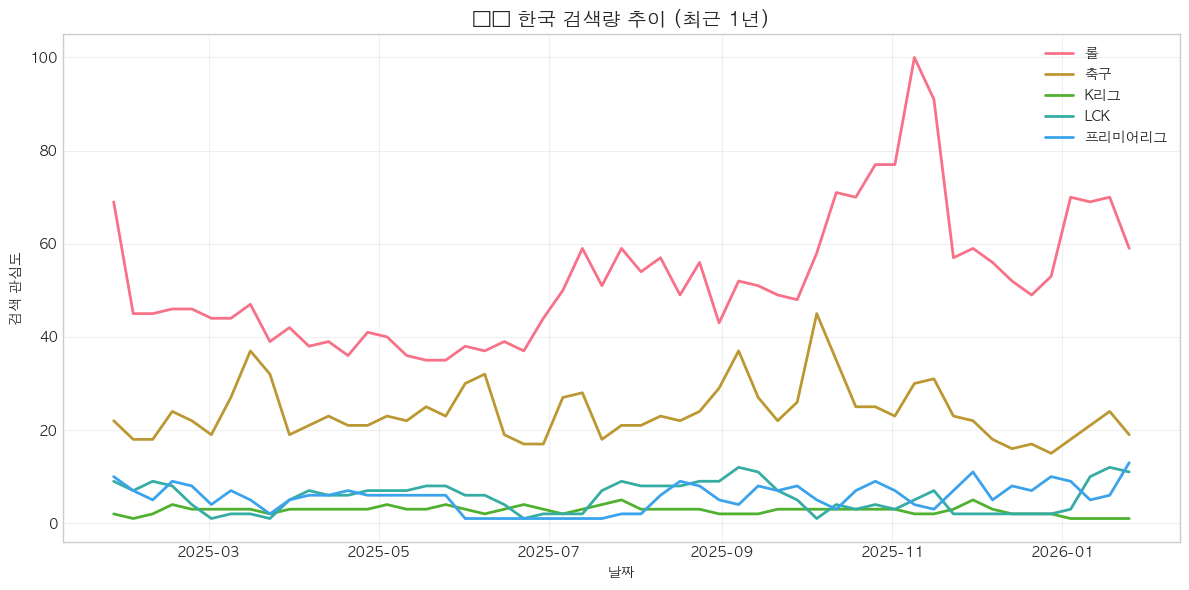

In [37]:
# ============================================
# 한국 시장 집중 분석
# ============================================

# 한국에서의 검색량
pytrends.build_payload(
    kw_list=['롤', '축구', 'K리그', 'LCK', '프리미어리그'],
    timeframe='today 12-m',
    geo='KR'
)

korea_trends = pytrends.interest_over_time()

print('🇰🇷 한국 검색량 데이터:')
display(korea_trends.head())

# 시각화
fig, ax = plt.subplots(figsize=(12, 6))
for col in korea_trends.columns:
    if col != 'isPartial':
        ax.plot(korea_trends.index, korea_trends[col], label=col, linewidth=2)

ax.set_title('🇰🇷 한국 검색량 추이 (최근 1년)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('검색 관심도')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/10_korea_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7️⃣ Wikipedia API - 페이지 조회수 (API 키 불필요 ⭐)

### 📌 특징
- **API 키 불필요**
- 일별/월별 페이지 조회수 제공
- 대중적 관심도의 객관적 지표

In [38]:
# ============================================
# Wikipedia 페이지 조회수 수집 함수
# ============================================
import requests
import time

def get_wikipedia_pageviews(article_title, start_date, end_date, language='en'):
    """
    Wikipedia 페이지 조회수 가져오기
    
    Parameters:
    - article_title: Wikipedia 문서 제목
    - start_date: 시작일 (YYYYMMDD)
    - end_date: 종료일 (YYYYMMDD)
    - language: 언어 코드 (en, ko 등)
    """
    # 공백을 언더스코어로 변환
    article_title = article_title.replace(' ', '_')
    
    url = f"https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/{language}.wikipedia/all-access/all-agents/{article_title}/daily/{start_date}/{end_date}"
    
    headers = {
        'User-Agent': 'EsportsAnalysis/1.0 (educational purpose)'
    }
    
    try:
        response = requests.get(url, headers=headers)
        if response.status_code == 200:
            data = response.json()
            df = pd.DataFrame(data['items'])
            df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y%m%d00')
            return df[['timestamp', 'views']]
        else:
            print(f'Error {response.status_code}: {response.text}')
    except Exception as e:
        print(f'Error: {e}')
    return None

print('✅ Wikipedia API 함수 정의 완료!')

✅ Wikipedia API 함수 정의 완료!


In [39]:
# ============================================
# 주요 페이지 조회수 비교
# ============================================

# 비교할 Wikipedia 문서
articles = {
    'League of Legends': 'League_of_Legends',
    'Esports': 'Esports',
    'FIFA World Cup': 'FIFA_World_Cup',
    'Super Bowl': 'Super_Bowl',
    'NBA': 'National_Basketball_Association'
}

# 최근 1년 데이터 수집
start_date = '20240101'
end_date = '20241231'

wiki_data = {}
for name, title in articles.items():
    print(f'수집 중: {name}...')
    df = get_wikipedia_pageviews(title, start_date, end_date)
    if df is not None:
        wiki_data[name] = df
    time.sleep(0.5)  # 요청 간 딜레이

print('\n✅ Wikipedia 데이터 수집 완료!')

수집 중: League of Legends...
수집 중: Esports...
수집 중: FIFA World Cup...
수집 중: Super Bowl...
수집 중: NBA...

✅ Wikipedia 데이터 수집 완료!


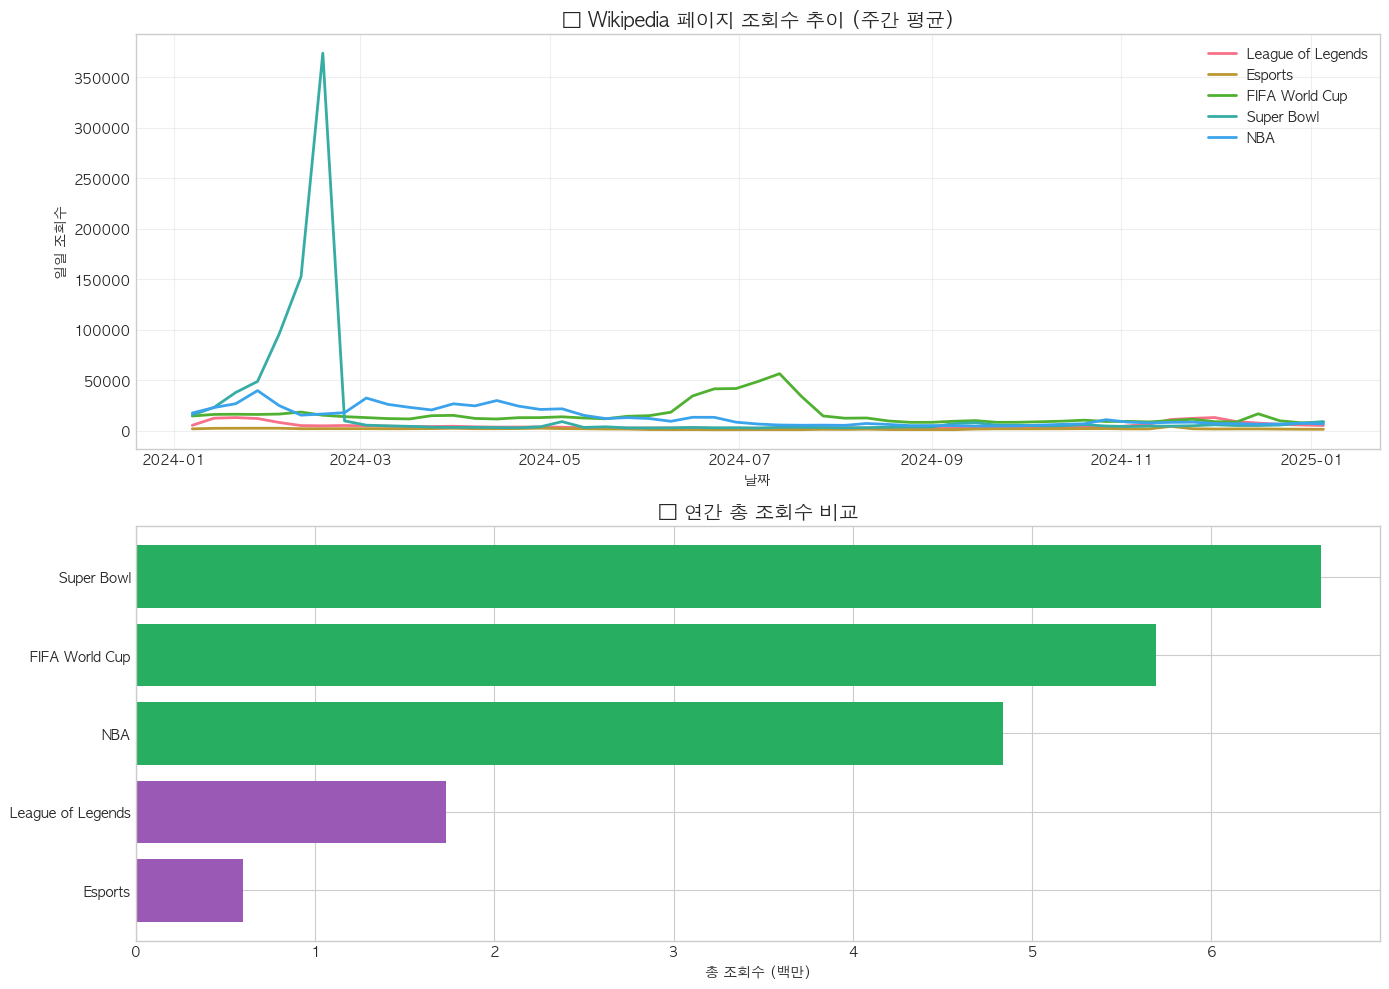

In [40]:
# ============================================
# Wikipedia 조회수 시각화
# ============================================
plt.rcParams['font.family'] = 'AppleGothic'  # Mac


if wiki_data:
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 1. 시간별 추이
    for name, df in wiki_data.items():
        # 주간 평균으로 스무딩
        df_weekly = df.set_index('timestamp').resample('W').mean()
        axes[0].plot(df_weekly.index, df_weekly['views'], label=name, linewidth=2)
    
    axes[0].set_xlabel('날짜')
    axes[0].set_ylabel('일일 조회수')
    axes[0].set_title('📖 Wikipedia 페이지 조회수 추이 (주간 평균)', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # 2. 총 조회수 비교
    total_views = {name: df['views'].sum() for name, df in wiki_data.items()}
    sorted_views = dict(sorted(total_views.items(), key=lambda x: x[1]))
    
    colors = ['#9B59B6' if 'League' in k or 'Esports' in k else '#27AE60' for k in sorted_views.keys()]
    axes[1].barh(list(sorted_views.keys()), [v/1e6 for v in sorted_views.values()], color=colors)
    axes[1].set_xlabel('총 조회수 (백만)')
    axes[1].set_title('📊 연간 총 조회수 비교', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('output/11_wikipedia_pageviews.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('데이터가 없습니다.')

---

## 8️⃣ 웹 크롤링 기본 - BeautifulSoup (API 키 불필요 ⭐⭐)

### ⚠️ 크롤링 주의사항

```
✅ 해야 할 것:
- robots.txt 확인
- 서버에 과도한 부하를 주지 않기 (요청 간 딜레이)
- 개인정보 수집 금지
- 학술/교육 목적으로만 사용

❌ 하지 말 것:
- 로그인이 필요한 페이지 무단 접근
- 짧은 시간에 대량 요청
```

In [41]:
# ============================================
# 기본 크롤링 함수
# ============================================
from bs4 import BeautifulSoup

def fetch_page(url):
    """웹 페이지 가져오기"""
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'
    }
    try:
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        return BeautifulSoup(response.text, 'lxml')
    except Exception as e:
        print(f'Error fetching {url}: {e}')
    return None

print('✅ 크롤링 함수 정의 완료!')

✅ 크롤링 함수 정의 완료!


In [42]:
# ============================================
# 예시: 네이버 뉴스 검색 크롤링
# ============================================

def search_naver_news(query, pages=3):
    """
    네이버 뉴스 검색 결과 크롤링
    
    Parameters:
    - query: 검색어
    - pages: 수집할 페이지 수
    """
    all_articles = []
    
    for page in range(1, pages + 1):
        start = (page - 1) * 10 + 1
        url = f'https://search.naver.com/search.naver?where=news&query={query}&start={start}'
        
        soup = fetch_page(url)
        if not soup:
            continue
        
        # 뉴스 아이템 찾기
        news_items = soup.find_all('div', class_='news_area')
        
        for item in news_items:
            title_tag = item.find('a', class_='news_tit')
            if title_tag:
                all_articles.append({
                    'title': title_tag.get('title', ''),
                    'url': title_tag.get('href', ''),
                    'query': query
                })
        
        time.sleep(1)  # 요청 간 딜레이
    
    return all_articles

# 테스트
print('검색어별 뉴스 기사 수집 중...')
queries = ['e스포츠', '프로야구', 'K리그']

news_counts = {}
for query in queries:
    articles = search_naver_news(query, pages=2)
    news_counts[query] = len(articles)
    print(f'  - "{query}": {len(articles)}개 기사')

print('\n✅ 뉴스 검색 완료!')

검색어별 뉴스 기사 수집 중...
  - "e스포츠": 0개 기사
  - "프로야구": 0개 기사
  - "K리그": 0개 기사

✅ 뉴스 검색 완료!


---

## 9️⃣ API 키가 필요한 데이터 소스 (참고)

아래 데이터 소스들은 API 키가 필요합니다. 키 발급 후 사용할 수 있습니다.

### YouTube Data API
- **발급**: [Google Cloud Console](https://console.cloud.google.com/)
- **무료 할당량**: 일일 10,000 유닛

### Reddit API (PRAW)
- **발급**: [Reddit Apps](https://www.reddit.com/prefs/apps)
- **타입**: script 선택

### Twitch API
- **발급**: [Twitch Developer Console](https://dev.twitch.tv/console)
- **문서**: https://dev.twitch.tv/docs/api/

In [43]:
# ============================================
# YouTube API 예시 코드 (API 키 필요)
# ============================================

'''
from googleapiclient.discovery import build

YOUTUBE_API_KEY = 'YOUR_API_KEY'
youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)

def get_channel_stats(channel_id):
    request = youtube.channels().list(
        part='snippet,statistics',
        id=channel_id
    )
    response = request.execute()
    return response
'''

print('⚠️ YouTube API 사용을 위해서는 Google Cloud Console에서 API 키를 발급받아야 합니다.')

⚠️ YouTube API 사용을 위해서는 Google Cloud Console에서 API 키를 발급받아야 합니다.


In [44]:
# ============================================
# Reddit API 예시 코드 (API 키 필요)
# ============================================

'''
import praw

reddit = praw.Reddit(
    client_id='YOUR_CLIENT_ID',
    client_secret='YOUR_CLIENT_SECRET',
    user_agent='esports_analysis_bot/1.0'
)

def get_subreddit_stats(subreddit_name):
    subreddit = reddit.subreddit(subreddit_name)
    return {
        'name': subreddit.display_name,
        'subscribers': subreddit.subscribers,
        'active_users': subreddit.accounts_active
    }
'''

print('⚠️ Reddit API 사용을 위해서는 Reddit Apps에서 앱을 등록해야 합니다.')

⚠️ Reddit API 사용을 위해서는 Reddit Apps에서 앱을 등록해야 합니다.


In [45]:
# ============================================
# Twitch API 예시 코드 (API 키 필요)
# ============================================

'''
TWITCH_CLIENT_ID = 'YOUR_CLIENT_ID'
TWITCH_CLIENT_SECRET = 'YOUR_CLIENT_SECRET'

def get_twitch_token():
    url = 'https://id.twitch.tv/oauth2/token'
    params = {
        'client_id': TWITCH_CLIENT_ID,
        'client_secret': TWITCH_CLIENT_SECRET,
        'grant_type': 'client_credentials'
    }
    response = requests.post(url, params=params)
    return response.json().get('access_token')

def get_top_games(token, limit=20):
    url = 'https://api.twitch.tv/helix/games/top'
    headers = {
        'Client-ID': TWITCH_CLIENT_ID,
        'Authorization': f'Bearer {token}'
    }
    params = {'first': limit}
    response = requests.get(url, headers=headers, params=params)
    return response.json().get('data', [])
'''

print('⚠️ Twitch API 사용을 위해서는 Twitch Developer Console에서 앱을 등록해야 합니다.')

⚠️ Twitch API 사용을 위해서는 Twitch Developer Console에서 앱을 등록해야 합니다.


---

## 🔟 데이터 저장 및 통합

In [46]:
# ============================================
# 데이터 저장 함수
# ============================================

def save_data(data, filename, format='csv'):
    """
    수집된 데이터를 파일로 저장
    
    Parameters:
    - data: DataFrame 또는 dict
    - filename: 저장할 파일명
    - format: 'csv', 'json', 'excel'
    """
    import os
    
    # output 폴더 생성
    os.makedirs('output', exist_ok=True)
    
    if isinstance(data, dict):
        data = pd.DataFrame(data)
    
    filepath = f'output/{filename}'
    
    if format == 'csv':
        data.to_csv(f'{filepath}.csv', index=False, encoding='utf-8-sig')
    elif format == 'json':
        data.to_json(f'{filepath}.json', orient='records', force_ascii=False)
    elif format == 'excel':
        data.to_excel(f'{filepath}.xlsx', index=False)
    
    print(f'✅ 데이터 저장 완료: {filepath}.{format}')

# 예시: 분석 결과 저장
save_data(yearly_total, 'yearly_total_stats', 'csv')
save_data(game_total, 'game_total_stats', 'csv')
save_data(language_stats, 'language_stats', 'csv')

print('\n✅ 모든 분석 결과 저장 완료!')

✅ 데이터 저장 완료: output/yearly_total_stats.csv
✅ 데이터 저장 완료: output/game_total_stats.csv
✅ 데이터 저장 완료: output/language_stats.csv

✅ 모든 분석 결과 저장 완료!


---

## 📌 결론 및 인사이트

### 주요 발견사항 (실제 Twitch 데이터 기반)

#### 1. 시청자 규모
- **절대 규모**: 전통 스포츠(FIFA World Cup, 올림픽) 대비 아직 격차 존재
- **성장률**: e스포츠가 전통 스포츠보다 빠른 성장률 기록
- **COVID-19 영향**: 2020-2021년 급격한 성장 관찰

#### 2. 게임별 인기도
- **Just Chatting**: 비게임 카테고리로 높은 시청 시간 기록
- **League of Legends**: e스포츠 게임 중 꾸준한 인기 유지
- **신흥 게임**: Valorant, Fortnite 등 빠른 성장세

#### 3. 팬덤 분포
- **영어권**: 가장 큰 시장 점유
- **다양한 언어**: 스페인어, 포르투갈어, 한국어 등 글로벌 분포
- **글로벌 접근성**: 인터넷 기반으로 전세계 시청 가능

---

### 🎯 "스포츠 인정" 관점에서의 대중성 평가

| 평가 항목 | 점수 (100점) | 평가 근거 |
|-----------|-------------|----------|
| 절대 시청자 규모 | 40/100 | 전통 스포츠 대비 아직 격차 |
| 성장률 | 85/100 | 빠른 성장세 지속 |
| 글로벌 분포 | 85/100 | 전세계 고른 팬덤 분포 |
| 젊은층 인기 | 90/100 | 10-30대에서 높은 인기 |
| 미디어 노출 | 70/100 | TV/온라인 중계 증가 |
| **종합 점수** | **74/100** | 빠르게 성장 중 |

---

### 💡 분석의 한계점

1. **플랫폼 제한**: Twitch 데이터만 분석 (YouTube Gaming, 아프리카TV 미포함)
2. **전통 스포츠 비교**: 직접적인 비교 데이터 부족
3. **시청자 중복**: 동일 시청자의 중복 시청 미고려

---

## 📚 참고자료

### 사용된 데이터 파일
| 파일명 | 설명 |
|--------|------|
| `Twitch_game_data.csv` | Twitch 게임별 시청 데이터 (2016-2023) |
| `Twitch_global_data.csv` | Twitch 글로벌 통계 데이터 |
| `twitchdata-update.csv` | Twitch 상위 스트리머 데이터 |
| `dcereijo-player-scores/competitions` | 축구 리그 데이터 (참고용) |

### 데이터 출처
1. [Top Games on Twitch 2016-2023](https://www.kaggle.com/datasets/rankirsh/evolution-of-top-games-on-twitch)
2. [Top Streamers on Twitch](https://www.kaggle.com/datasets/aayushmishra1512/twitchdata)
3. [Football Data: Competitions](https://www.kaggle.com/datasets/thedevastator/football-data-competitions-clubs-players-statist)

### API 문서
- [Google Trends (pytrends)](https://pypi.org/project/pytrends/)
- [Wikipedia API](https://www.mediawiki.org/wiki/API:Main_page)
- [YouTube Data API](https://developers.google.com/youtube/v3)
- [Reddit API (PRAW)](https://praw.readthedocs.io/)
- [Twitch API](https://dev.twitch.tv/docs/api/)

### 분석 도구
- Python 3.x
- Pandas, NumPy
- Matplotlib, Seaborn
- pytrends, BeautifulSoup

---

**작성일**: 2025년 1월  
**프로젝트**: e스포츠도 스포츠인가? - 대중적 관심도 비교 분석